# Trustline Loan Default: Complete Project Notebook

**Project:** Trustline Loan Default Prediction

**Student:** Madu Miracle

**Dataset:** Loan_default.csv, 255,347 loan records and 18 columns

**Target Variable:** `Default` (1 = the borrower defaulted on the loan, 0 = the loan was repaid)

**Problem Type:** Binary classification (supervised learning)

### Business framing

Trustline is a consumer lending business. Every approved loan is a bet. The lender earns interest if
the borrower repays and loses most of the principal if the borrower defaults. What I want to build here
is a model that estimates, using only the information available **at application time** (age, income,
credit score, employment history, loan terms and so on), how likely an applicant is to default.

A model that works gives the credit team three things it does not currently have. It can screen
applications, so that risky ones go to a human instead of being auto approved. It can price risk, so the
interest rate charged reflects the actual probability of loss. And it can show which borrower
characteristics carry the signal, which is useful even if nobody ever deploys the model.

### Notebook structure

I have combined every stage of the project into this one document:

1. Data Understanding, inspecting the raw file and recording its baseline condition
2. Exploratory Data Analysis, looking for the patterns that separate defaulters from repayers
3. Data Preparation, cleaning, encoding, scaling, splitting and building a reusable pipeline
4. Model Development, training and comparing Logistic Regression against Random Forest, XGBoost and AdaBoost
5. Model Evaluation, confusion matrices, curves, threshold selection and error analysis
6. Application Integration, saving the artefacts and building the Streamlit frontend



## Section 0: Environment setup

Everything the notebook needs is imported in one place at the top, along with the display settings and
the random seed.


In [3]:
# ---------- Core data handling ----------
import numpy as np                      # numerical arrays and maths functions
import pandas as pd                     # DataFrames for loading and manipulating tabular data

# ---------- Visualisation ----------
import matplotlib.pyplot as plt         # the base plotting library
import seaborn as sns                   # statistical plots built on matplotlib, with nicer defaults

# ---------- Scikit-learn: data preparation ----------
from sklearn.model_selection import train_test_split      # splits data into training and testing sets
from sklearn.model_selection import cross_val_score       # runs k-fold cross validation on a model
from sklearn.model_selection import StratifiedKFold       # cross validation that keeps the class balance
from sklearn.model_selection import GridSearchCV          # searches over hyper-parameter values
from sklearn.preprocessing import StandardScaler          # rescales numeric features to mean 0, std 1
from sklearn.preprocessing import OneHotEncoder           # turns text categories into 0/1 columns
from sklearn.compose import ColumnTransformer             # applies different transformers to different columns
from sklearn.pipeline import Pipeline                     # chains preprocessing and a model into one object

# ---------- The four classification algorithms ----------
from sklearn.linear_model import LogisticRegression       # the simple, interpretable BASELINE
from sklearn.ensemble import RandomForestClassifier       # candidate 1: many decision trees, averaged
from xgboost import XGBClassifier                         # candidate 2: optimised gradient boosted trees
from sklearn.ensemble import AdaBoostClassifier           # candidate 3: trees boosted by re-weighting rows

# ---------- Evaluation metrics ----------
from sklearn.metrics import accuracy_score                # share of all predictions that were correct
from sklearn.metrics import precision_score               # of those predicted to default, how many did
from sklearn.metrics import recall_score                  # of those who actually defaulted, how many we caught
from sklearn.metrics import f1_score                      # harmonic mean of precision and recall
from sklearn.metrics import roc_auc_score                 # ranking quality, independent of the threshold
from sklearn.metrics import confusion_matrix              # table of correct against incorrect predictions
from sklearn.metrics import classification_report         # precision, recall and F1 per class
from sklearn.metrics import roc_curve                     # the points needed to draw an ROC curve
from sklearn.metrics import precision_recall_curve        # the points needed to draw a PR curve
from sklearn.metrics import average_precision_score       # area under the Precision-Recall curve

# ---------- Display and reproducibility ----------
pd.set_option('display.max_columns', 50)     # show up to 50 columns instead of truncating them
pd.set_option('display.width', 200)          # allow wide output before wrapping
sns.set_style('whitegrid')                   # light grid background, easier to read
plt.rcParams['figure.figsize'] = (10, 5)     # default chart size for the whole notebook
plt.rcParams['axes.titlesize'] = 13          # slightly larger chart titles

RANDOM_STATE = 42                            # one fixed seed, reused everywhere

import warnings                              # controls Python warning messages
warnings.filterwarnings('ignore')            # hide non-critical warnings so the output stays readable

print("All libraries imported successfully.")


All libraries imported successfully.


The imports fall into four groups: the data handling and plotting libraries, the scikit-learn tools I
use to prepare the data, the four algorithms I am comparing, and the metrics I score them with.

The line that matters most for reproducibility is `RANDOM_STATE = 42`. Splitting the data and building
trees both involve randomness, so without a fixed seed I would get slightly different numbers every time
I ran the notebook and would not be able to tell a real improvement from noise. Passing the same seed
everywhere means anybody who runs this gets the split, the trees and the scores I got.

The display settings are cosmetic. They stop pandas cutting off wide tables and give every chart the
same default size.


# Section 1: Data Understanding

Before touching anything, I want to answer the basic factual questions about the file. How big is it,
what does each column hold, are there gaps or duplicates, how is the target distributed, and do the
numbers look believable for a real loan book.

I change nothing in this section. The point is to record the baseline condition of the data so that any
cleaning I do later is justified by something I actually found rather than by habit.


## 1.1 Loading the dataset

In [4]:
# Read the CSV file from disk into a pandas DataFrame.
# The path below is the Colab default. Change it to 'Loan_default.csv' if you run this locally.
df = pd.read_csv('/content/Loan_default.csv')

# .shape returns a tuple: (number of rows, number of columns)
print("Number of rows    :", df.shape[0])
print("Number of columns :", df.shape[1])

# .head() shows the first 5 rows so we can eyeball the actual values
df.head()


Number of rows    : 255347
Number of columns : 18


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


`pd.read_csv` loads the file into a DataFrame called `df`, which every later step works from. The
dataset has 255,347 loan records described by 18 columns.

Printing the first five rows is a cheap sanity check. It tells me the header row parsed correctly, the
delimiter is a comma, and the values under each heading are the sort of thing the heading promises: ages
in the twenties to sixties, incomes in the tens of thousands, credit scores in the hundreds. If the file
had been semicolon separated or had a stray extra header line, this is where it would show up.


## 1.2 The data dictionary

In [5]:
# A small reference table describing what each column means.
# This is written by hand from the dataset documentation, not computed from the data.
data_dictionary = pd.DataFrame({
    'Column': [
        'LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
        'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education',
        'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents',
        'LoanPurpose', 'HasCoSigner', 'Default'
    ],
    'Description': [
        'Unique identifier for each loan record',
        'Age of the borrower in years',
        'Annual income of the borrower',
        'Amount of money borrowed',
        'Credit score of the borrower, higher means a better credit history',
        'Number of months the borrower has been employed',
        'Number of open credit lines the borrower holds',
        'Annual interest rate charged on the loan, in percent',
        'Length of the loan in months',
        'Debt-to-Income ratio, monthly debt payments divided by monthly income',
        'Highest education level attained',
        'Type of employment held by the borrower',
        'Marital status of the borrower',
        'Whether the borrower has a mortgage',
        'Whether the borrower has dependents',
        'What the loan will be used for',
        'Whether the loan has a co-signer',
        'TARGET: 1 = borrower defaulted, 0 = borrower repaid'
    ],
    'Role': [
        'Identifier', 'Feature', 'Feature', 'Feature', 'Feature', 'Feature',
        'Feature', 'Feature', 'Feature', 'Feature', 'Feature', 'Feature',
        'Feature', 'Feature', 'Feature', 'Feature', 'Feature', 'Target'
    ]
})

data_dictionary


,Column,Description,Role
0,LoanID,Unique identifier for each loan record,Identifier
1,Age,Age of the borrower in years,Feature
2,Income,Annual income of the borrower,Feature
3,LoanAmount,Amount of money borrowed,Feature
4,CreditScore,"Credit score of the borrower, higher means a b...",Feature
5,MonthsEmployed,Number of months the borrower has been employed,Feature
6,NumCreditLines,Number of open credit lines the borrower holds,Feature
7,InterestRate,"Annual interest rate charged on the loan, in p...",Feature
8,LoanTerm,Length of the loan in months,Feature
9,DTIRatio,"Debt-to-Income ratio, monthly debt payments di...",Feature


Writing the data dictionary out by hand forces an early decision about what each column is for, which
is the real value of doing it.

`LoanID` is an identifier and not a feature. It carries no information about whether somebody repays, so
it has to come out before modelling. `Default` is the target. The remaining 16 columns are the candidate
features. Having this settled now means I am not guessing at column roles halfway through Section 3.

The second reason for the table is interpretability. A model that "uses DTIRatio" means nothing to a
credit officer unless somebody has written down that DTIRatio is monthly debt divided by monthly income.


## 1.3 Column types and memory

In [6]:
# .info() prints, for every column: its name, how many non-null values it holds,
# its data type, and the total memory the DataFrame occupies.
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

Three things to read off this output.

Every column reports the full 255,347 non-null entries, which is the first hint that there are no
missing values to deal with. Nine columns are numeric and eight hold text, plus the integer target.
Scikit-learn cannot train on text, so those eight text columns will need encoding later, and spotting
them now is what makes that step planned rather than a reaction to an error message.

The memory figure is small enough that the whole DataFrame sits comfortably in RAM, so I do not need to
read the file in chunks or work out of core.


## 1.4 Checking for missing values

In [7]:
# .isnull() returns a same-shaped frame of True/False where True means the value is missing.
# .sum() then counts the True values down each column.
missing_counts = df.isnull().sum()

# Express those counts as a percentage of all rows, rounded to 2 decimal places.
missing_percent = (missing_counts / len(df) * 100).round(2)

# Put the counts and the percentages side by side.
missing_summary = pd.DataFrame({
    'Missing Values': missing_counts,
    'Percent Missing': missing_percent
})

print("Total missing values in the entire dataset:", df.isnull().sum().sum())
missing_summary


Total missing values in the entire dataset: 0


,Missing Values,Percent Missing
LoanID,0,0.0
Age,0,0.0
Income,0,0.0
LoanAmount,0,0.0
CreditScore,0,0.0
MonthsEmployed,0,0.0
NumCreditLines,0,0.0
InterestRate,0,0.0
LoanTerm,0,0.0
DTIRatio,0,0.0


There are no missing values anywhere in the dataset.

I am stating that explicitly rather than assuming it, because it removes a whole stage of work. No
imputation, no dropped rows, no missingness indicator columns. If a column had been say 30% empty I
would have had to choose between filling it with the median, treating the gap as its own category, or
dropping the column, and each of those choices would change the model in ways I would then have to
defend. None of that applies here.


## 1.5 Checking for duplicate records

In [8]:
# .duplicated() flags rows that are an exact copy of an earlier row across ALL columns.
full_duplicates = df.duplicated().sum()

# Loan IDs are supposed to be unique, so a repeated LoanID would also point to a problem.
duplicate_ids = df['LoanID'].duplicated().sum()

print("Fully duplicated rows      :", full_duplicates)
print("Duplicated LoanID values   :", duplicate_ids)
print("Unique LoanID values       :", df['LoanID'].nunique())
print("Total rows in the dataset  :", len(df))


Fully duplicated rows      : 0
Duplicated LoanID values   : 0
Unique LoanID values       : 255347
Total rows in the dataset  : 255347


I checked duplication two ways, whole rows and repeated loan IDs, and both come back clean. The number
of unique IDs equals the number of rows, so every record is a distinct loan.

This matters more than it looks. Duplicates inflate the apparent sample size, they over-weight whichever
borrowers happen to be repeated, and worst of all the same record can end up in both the training and
the test set, which makes the test score look better than the model deserves.


## 1.6 The target variable

In [9]:
# Count how many loans fall into each class of the target column.
target_counts = df['Default'].value_counts()

# The same counts as percentages of the whole dataset.
target_percent = df['Default'].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    'Count': target_counts,
    'Percentage': target_percent.round(2)
})
target_summary.index = ['0 - Repaid (No Default)', '1 - Defaulted']

print(target_summary)
print()

# How many repaid loans there are for every one default.
imbalance_ratio = target_counts[0] / target_counts[1]
print(f"Imbalance ratio: {imbalance_ratio:.2f} repaid loans for every 1 default")


                          Count  Percentage
0 - Repaid (No Default)  225694       88.39
1 - Defaulted             29653       11.61

Imbalance ratio: 7.61 repaid loans for every 1 default


About 88.4% of the loans were repaid and 11.6% defaulted, which is roughly 7.6 repaid loans for every
default. This is the single most consequential fact in the dataset and it shapes almost every decision
that follows.

The first consequence is that accuracy becomes a misleading metric. A model that ignores the data
completely and predicts "no default" for every applicant scores 88.4% accuracy while catching not one
defaulter. That model is worthless to a lender but looks excellent on the headline number. So I will
judge models mainly on recall, which is the share of real defaulters caught, and on ROC-AUC and average
precision, which measure how well the model ranks risk. Accuracy stays in the tables as a secondary
figure.

The second consequence is that the train/test split has to be stratified, otherwise an unlucky split
could hand me a test set with a different default rate from the one the business actually faces.


## 1.7 Descriptive statistics for the numeric columns

In [10]:
# Select every column whose data type is numeric.
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove the target. Default is numeric but it is not an input feature.
numeric_features = [col for col in numeric_columns if col != 'Default']

print("Numeric feature columns:", numeric_features)
print()

# .describe() reports count, mean, std, min, the three quartiles and max.
# .T transposes it so each feature is a row, which reads more easily.
df[numeric_features].describe().T.round(2)


Numeric feature columns: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']



,count,mean,std,min,25%,50%,75%,max
Age,255347.0,43.50,14.99,18.0,31.00,43.00,56.00,69.0
Income,255347.0,82499.30,38963.01,15000.0,48825.50,82466.00,116219.00,149999.0
LoanAmount,255347.0,127578.87,70840.71,5000.0,66156.00,127556.00,188985.00,249999.0
CreditScore,255347.0,574.26,158.90,300.0,437.00,574.00,712.00,849.0
MonthsEmployed,255347.0,59.54,34.64,0.0,30.00,60.00,90.00,119.0
NumCreditLines,255347.0,2.50,1.12,1.0,2.00,2.00,3.00,4.0
InterestRate,255347.0,13.49,6.64,2.0,7.77,13.46,19.25,25.0
LoanTerm,255347.0,36.03,16.97,12.0,24.00,36.00,48.00,60.0
DTIRatio,255347.0,0.50,0.23,0.1,0.30,0.50,0.70,0.9


Every range here is plausible for a real loan book, and there are no impossible values sitting in the
data. No negative incomes, nobody aged 200, no credit scores outside the usual band.

Age runs from 18 to 69 and averages about 43. Income spans roughly 15,000 to 150,000 with a mean near
82,500. LoanAmount runs from about 5,000 to 250,000, averaging around 127,600. CreditScore covers the
standard 300 to 850 range and averages 574. InterestRate sits between 2% and 25%, DTIRatio between 0.10
and 0.90. LoanTerm only takes five values from 12 to 60 months, so it behaves more like a category than
a continuous number.

The other thing this table shows is a scale problem. Income is measured in tens of thousands while
DTIRatio lives between 0 and 1. Logistic Regression is sensitive to that difference because it fits a
coefficient per feature, so Section 3 rescales the numeric columns.


## 1.8 Descriptive statistics for the categorical columns

In [11]:
# Select the text columns. These are the categorical variables.
categorical_columns = df.select_dtypes(include=['object', 'string']).columns.tolist()

# LoanID is text but it is an identifier, not a real category, so exclude it.
categorical_features = [col for col in categorical_columns if col != 'LoanID']

print("Categorical feature columns:", categorical_features)
print()

# Print how many distinct values each column has, what they are, and how often each occurs.
for col in categorical_features:
    print(f"--- {col} ---")
    print("Number of unique categories:", df[col].nunique())
    print(df[col].value_counts())
    print()


Categorical feature columns: ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']

--- Education ---
Number of unique categories: 4
Education
Bachelor's     64366
High School    63903
Master's       63541
PhD            63537
Name: count, dtype: int64

--- EmploymentType ---
Number of unique categories: 4
EmploymentType
Part-time        64161
Unemployed       63824
Self-employed    63706
Full-time        63656
Name: count, dtype: int64

--- MaritalStatus ---
Number of unique categories: 3
MaritalStatus
Married     85302
Divorced    85033
Single      85012
Name: count, dtype: int64

--- HasMortgage ---
Number of unique categories: 2
HasMortgage
Yes    127677
No     127670
Name: count, dtype: int64

--- HasDependents ---
Number of unique categories: 2
HasDependents
Yes    127742
No     127605
Name: count, dtype: int64

--- LoanPurpose ---
Number of unique categories: 5
LoanPurpose
Business     51298
Home         51286
Education   

The categorical columns are in good shape. The largest number of categories in any column is five, in
`LoanPurpose`, and the rest have two, three or four. Low cardinality like that means one-hot encoding
will only add a handful of columns rather than blowing up the feature space.

The categories are also evenly filled. There is no category sitting at a few dozen rows that I would
need to merge into an "Other" bucket to stop the encoder producing a column that is almost all zeros.

Finally, the values are clean. No typos, no "Yes" against "yes" casing mismatches, no trailing spaces.
Any of those would be encoded as separate categories and quietly split the data. Since none are present,
no text standardisation step is needed.


## 1.9 What the data understanding stage established

The dataset is 255,347 rows by 18 columns with no missing values and no duplicate records. The target
splits 88.4% repaid against 11.6% defaulted. There are nine numeric features, all inside realistic
ranges but on very different scales, and seven categorical features, all low cardinality and clean.
`LoanID` is an identifier that has to be dropped.

Because the file is this clean, Section 3 will be short. There is no imputation and no de-duplication to
do, so the real preparation work is encoding the seven text columns and rescaling the nine numeric ones.

The class imbalance is what carries forward into everything else. It tells me to stratify the split, to
compare models on recall and ranking metrics rather than accuracy, and to think about class weighting so
the models do not simply learn to answer "no default" every time.


# Section 2: Exploratory Data Analysis

Section 1 established what the data is. This section asks what it says, and specifically which borrower
characteristics separate the people who defaulted from the people who repaid.

I work outward from the target. First the target on its own, then the distribution of each numeric
feature, then how each feature relates to default, then how the features relate to each other. Every
chart is answering a question I can state before I draw it.


## 2.1 Visualising the class imbalance

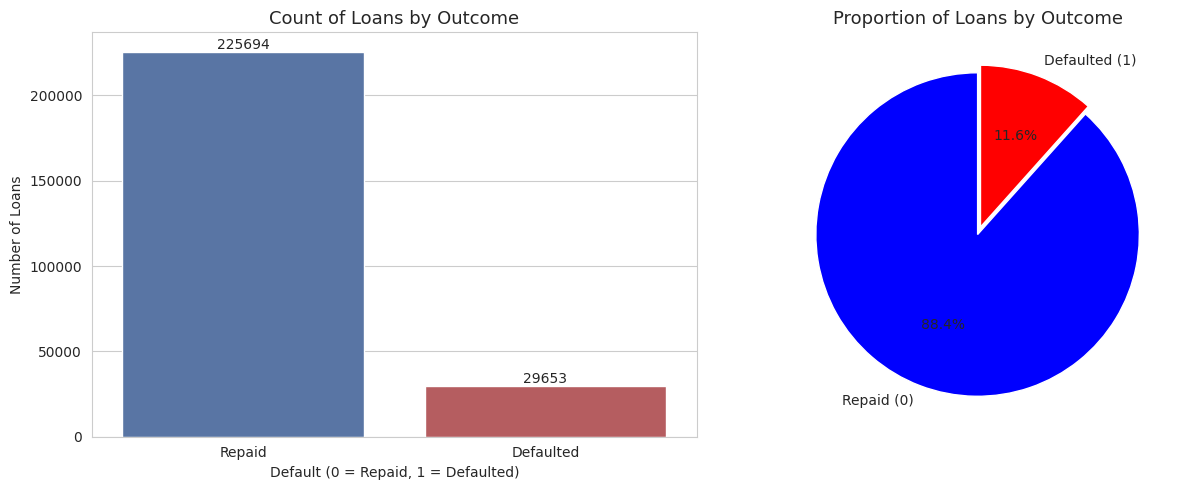

In [58]:
# One figure with two plots side by side (1 row, 2 columns).
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ---- LEFT: bar chart of raw counts ----
sns.countplot(data=df, x='Default', ax=axes[0], palette=['#4C72B0', '#C44E52'])
axes[0].set_title('Count of Loans by Outcome')
axes[0].set_xlabel('Default (0 = Repaid, 1 = Defaulted)')
axes[0].set_ylabel('Number of Loans')
axes[0].set_xticklabels(['Repaid', 'Defaulted'])

# Write the exact count above each bar so nobody has to estimate from the axis.
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d')

# ---- RIGHT: pie chart of proportions ----
axes[1].pie(
    df['Default'].value_counts(),
    labels=['Repaid (0)', 'Defaulted (1)'],
    autopct='%1.1f%%',                       # show each slice's percentage to 1 decimal
    colors=['blue', 'red'],
    startangle=90,
    explode=(0, 0.05)                        # pull the small slice out slightly
)
axes[1].set_title('Proportion of Loans by Outcome')

plt.tight_layout()
plt.show()


The two views make different points, which is why I drew both.

In absolute terms there are still about 29,650 defaults, and that is plenty of examples for a model to
learn from. In proportional terms those defaults are only 11.6% of the book, which is small enough that
a model optimising overall error will be tempted to ignore them entirely.

So the picture is: enough minority data to train on, but a minority small enough to get trampled. That
is what justifies using recall and ROC-AUC as the metrics I actually select on.


## 2.2 Distribution of each numeric feature

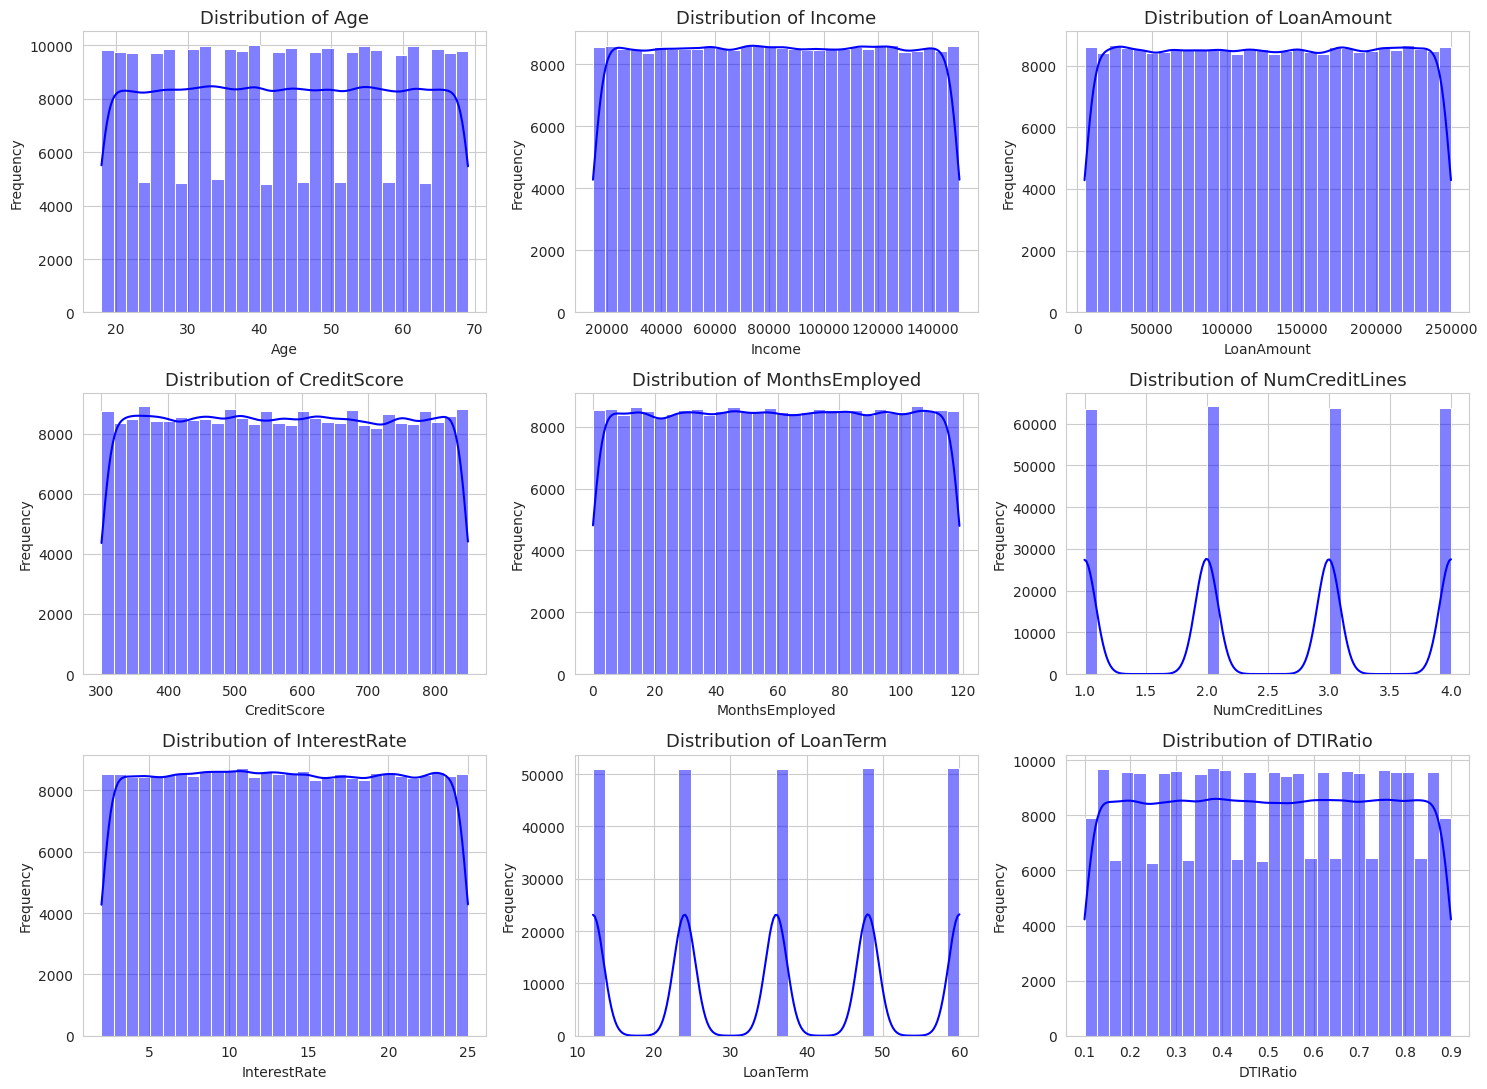

In [60]:
# A 3 x 3 grid, one histogram per numeric feature.
fig, axes = plt.subplots(3, 3, figsize=(15, 11))

# .flatten() turns the 3x3 grid into a simple list we can index with one number.
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.histplot(data=df, x=col, bins=30, kde=True, ax=axes[i], color='blue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


What stands out is how flat these distributions are. Age, Income, LoanAmount, CreditScore,
MonthsEmployed, InterestRate and DTIRatio are all close to uniform rather than bell shaped, and
NumCreditLines and LoanTerm only take a handful of discrete values.

That has two consequences. There is no long right tail anywhere, so I have no outlier problem and no
reason to apply log transforms, which a skewed financial dataset would normally need. But uniform
features also carry less natural separation than clustered ones, so I should expect each feature on its
own to be a weak predictor and the model's power to come from combining them.


## 2.3 Numeric features compared across the two outcomes

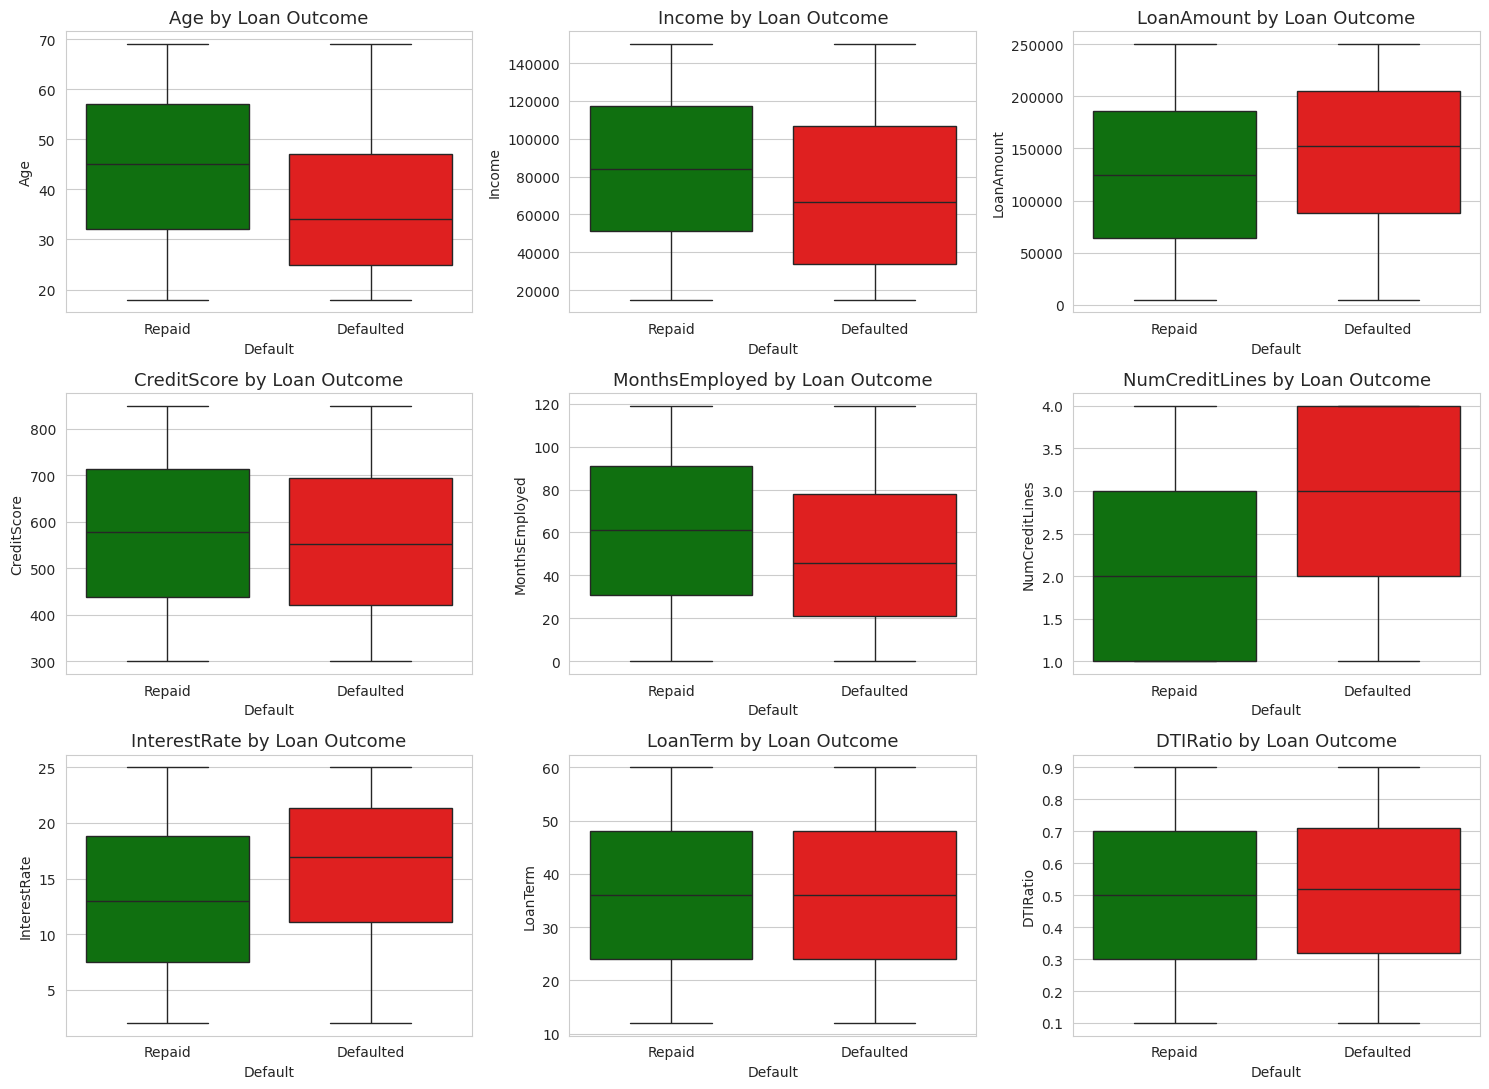

In [59]:
# Same 3x3 grid, this time boxplots split by outcome.
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    # A boxplot per class shows the median, the middle 50% of values and the spread.
    sns.boxplot(data=df, x='Default', y=col, ax=axes[i], palette=['green', 'red'])
    axes[i].set_title(f'{col} by Loan Outcome')
    axes[i].set_xlabel('Default')
    axes[i].set_xticklabels(['Repaid', 'Defaulted'])

plt.tight_layout()
plt.show()


In [15]:
# Group by the target and take the mean of every numeric feature inside each group.
group_means = df.groupby('Default')[numeric_features].mean().T   # .T puts features on the rows

group_means.columns = ['Repaid (0)', 'Defaulted (1)']

# How far apart the two group means are, in percentage terms.
group_means['Difference %'] = (
    (group_means['Defaulted (1)'] - group_means['Repaid (0)']) / group_means['Repaid (0)'] * 100
)

# Sort by the size of the gap so the strongest signals sit at the top.
group_means = group_means.reindex(group_means['Difference %'].abs().sort_values(ascending=False).index)

group_means.round(2)


,Repaid (0),Defaulted (1),Difference %
InterestRate,13.18,15.90,20.64
Age,44.41,36.56,-17.68
MonthsEmployed,60.76,50.24,-17.33
LoanAmount,125353.66,144515.31,15.29
Income,83899.17,71844.72,-14.37
NumCreditLines,2.49,2.59,3.97
CreditScore,576.23,559.29,-2.94
DTIRatio,0.50,0.51,2.78
LoanTerm,36.02,36.05,0.08


Ranking the features by how far apart the two groups sit produces a story that makes economic sense.

Interest rate shows the biggest gap, about 20% higher on defaulted loans. Some of that is circular,
since Trustline already charges risky applicants more, and some of it is causal, because a higher rate
is a heavier repayment burden. Age comes next: defaulters are about eight years younger on average,
which fits with shorter financial track records and thinner savings. Then months employed, where
defaulters have been in work for less time, and then income and loan amount, which point the same way
between them. Defaulters earn less and borrow more, so the loan is large relative to what they can
service.

Credit score is lower for defaulters as you would expect, though the gap is only about 3%, and DTIRatio
and number of credit lines barely move at all.

The boxplots add the caveat that the table hides. Every feature shows heavy overlap between the two
groups. Not one of them cleanly separates defaulters from repayers, and that overlap is exactly why a
model is needed. The signal lives in the combination, not in any single column.


## 2.4 Default rate within each category

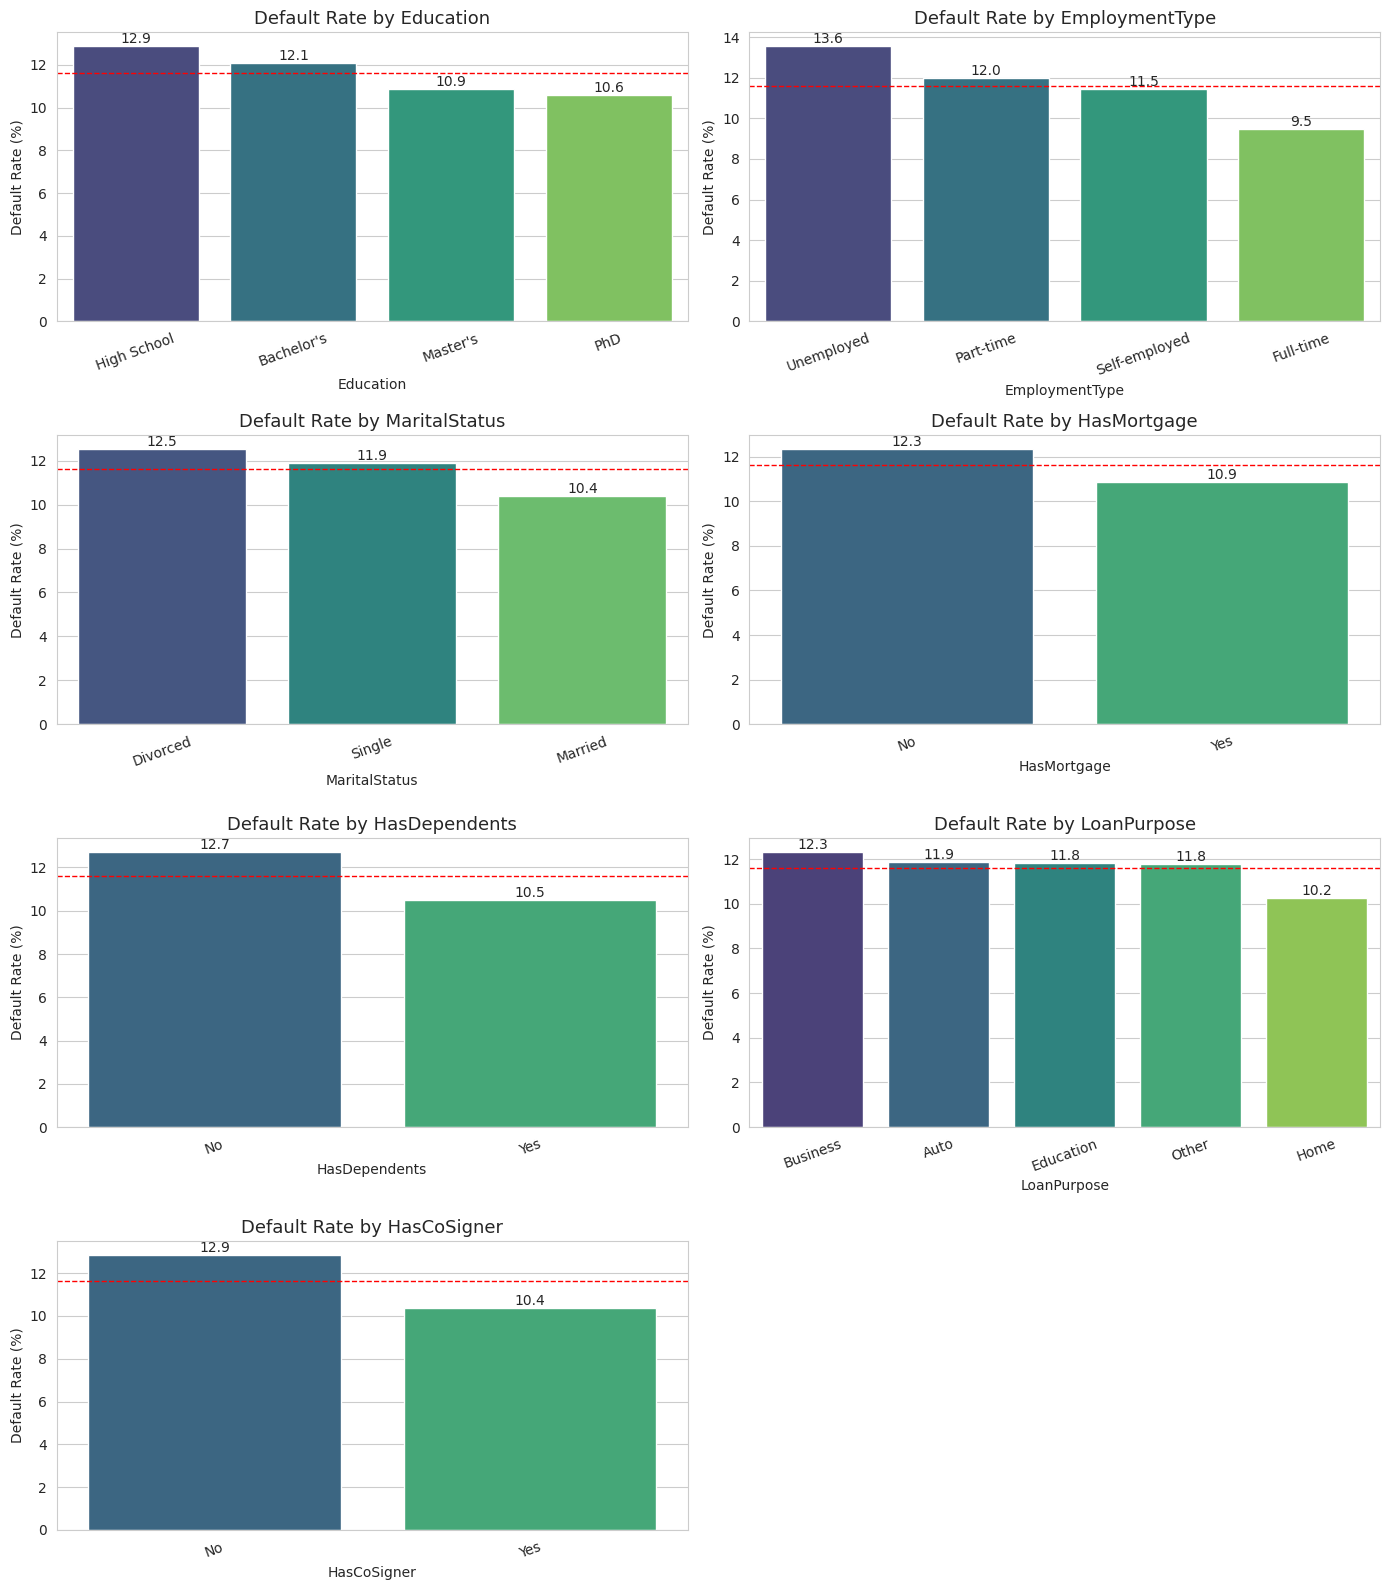

In [16]:
# A grid with room for all seven categorical features (4 rows x 2 columns = 8 panels).
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    # Default is coded 0/1, so the MEAN of Default inside a group is that group's default RATE.
    rates = df.groupby(col)['Default'].mean().sort_values(ascending=False) * 100

    sns.barplot(x=rates.index, y=rates.values, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Default Rate by {col}')
    axes[i].set_ylabel('Default Rate (%)')
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x', rotation=20)

    # A dashed line at the overall 11.6% base rate, for comparison.
    axes[i].axhline(df['Default'].mean() * 100, color='red', linestyle='--', linewidth=1)

    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.1f')

# Only seven categorical features, so hide the unused eighth panel.
axes[7].axis('off')

plt.tight_layout()
plt.show()


In [17]:
# The same information as a sorted table, which is easier to quote in a report.
for col in categorical_features:
    summary = df.groupby(col)['Default'].agg(['count', 'mean'])
    summary.columns = ['Number of Loans', 'Default Rate']
    summary['Default Rate %'] = (summary['Default Rate'] * 100).round(2)
    summary = summary.drop(columns='Default Rate').sort_values('Default Rate %', ascending=False)
    print(f"--- Default rate by {col} ---")
    print(summary)
    print()


--- Default rate by Education ---
             Number of Loans  Default Rate %
Education                                   
High School            63903           12.88
Bachelor's             64366           12.10
Master's               63541           10.87
PhD                    63537           10.59

--- Default rate by EmploymentType ---
                Number of Loans  Default Rate %
EmploymentType                                 
Unemployed                63824           13.55
Part-time                 64161           11.97
Self-employed             63706           11.46
Full-time                 63656            9.46

--- Default rate by MaritalStatus ---
               Number of Loans  Default Rate %
MaritalStatus                                 
Divorced                 85033           12.53
Single                   85012           11.91
Married                  85302           10.40

--- Default rate by HasMortgage ---
             Number of Loans  Default Rate %
HasMortgage 

The red line on each panel is the overall 11.6% default rate, so any bar above it marks a group that
defaults more often than the book as a whole.

Employment type gives the clearest signal. Unemployed borrowers default at 13.6% against 9.5% for
full-time employees, with part-time and self-employed in between. Income security is doing the work
there. Co-signers matter too, 12.9% without one against 10.4% with one, which reads both as a second
source of repayment and as a screening signal, since somebody else was willing to vouch for the
borrower.

Having a mortgage or dependents both go with lower default rates, around 10.5% to 10.9% against 12.3%
to 12.7% for borrowers without them. I read that as a stability proxy rather than a cause. Education
trends the way you would expect, from 12.9% for high school down to 10.6% for PhD holders. Marital
status and loan purpose barely move off the base rate.

None of these gaps are large on their own, which repeats the message from 2.3. Many weak signals, no
strong ones.


## 2.5 Correlation between numeric features

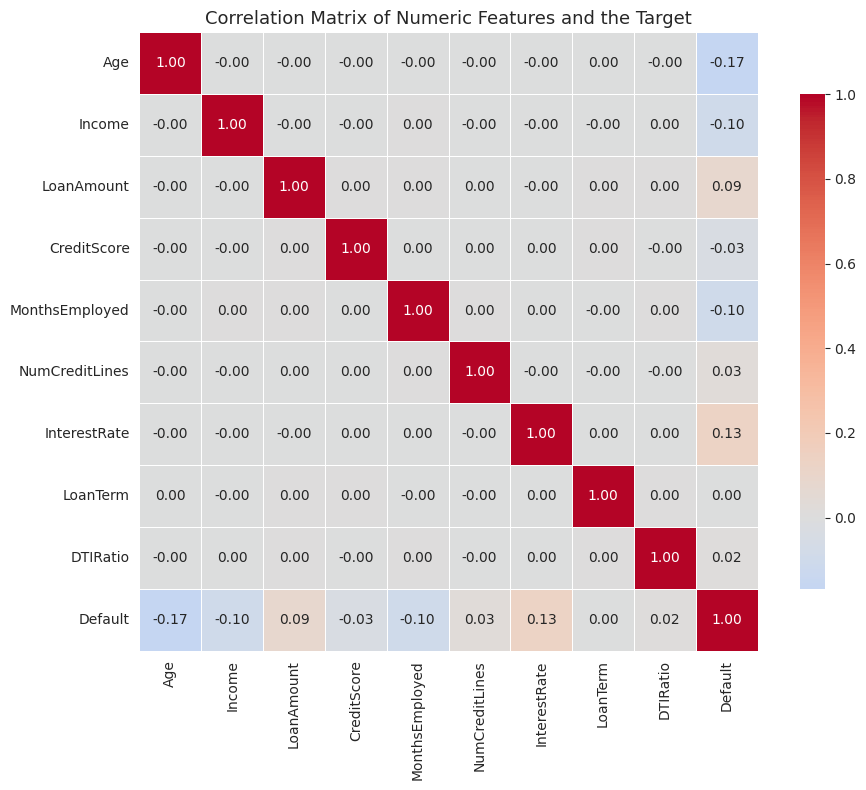

In [18]:
# The pairwise correlation matrix for the numeric features plus the target.
correlation_matrix = df[numeric_features + ['Default']].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,          # print the correlation inside each square
    fmt='.2f',
    cmap='coolwarm',     # blue for negative, red for positive
    center=0,            # anchor the colour scale so zero is white
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Matrix of Numeric Features and the Target')
plt.tight_layout()
plt.show()


In [19]:
# Pull out just the target column: how each feature correlates with Default.
target_correlation = correlation_matrix['Default'].drop('Default')

# Sort by absolute strength so the most informative sit first, whatever the sign.
target_correlation = target_correlation.reindex(
    target_correlation.abs().sort_values(ascending=False).index
)

print("Correlation of each numeric feature with Default, strongest first:")
print(target_correlation.round(4))


Correlation of each numeric feature with Default, strongest first:
Age              -0.1678
InterestRate      0.1313
Income           -0.0991
MonthsEmployed   -0.0974
LoanAmount        0.0867
CreditScore      -0.0342
NumCreditLines    0.0283
DTIRatio          0.0192
LoanTerm          0.0005
Name: Default, dtype: float64


Two things come out of this.

The features are essentially uncorrelated with each other. Every off-diagonal value sits near zero,
which means there is no multicollinearity to fix and no redundant column to drop. That is good news for
Logistic Regression in particular, because correlated inputs make its coefficients unstable and hard to
read.

Every individual correlation with the target is weak. Age is the strongest at about -0.17, then interest
rate at +0.13, and the rest fall away from there. I do not treat that as a reason to abandon the project.
Correlation only measures straight line relationships between one feature and the target, and it is
blind to interactions. Tree based models pick up exactly the kind of structure it cannot see, which is
the analytical reason I am testing ensembles alongside the linear baseline rather than stopping at
Logistic Regression.


## 2.6 A closer look at the strongest numeric signals

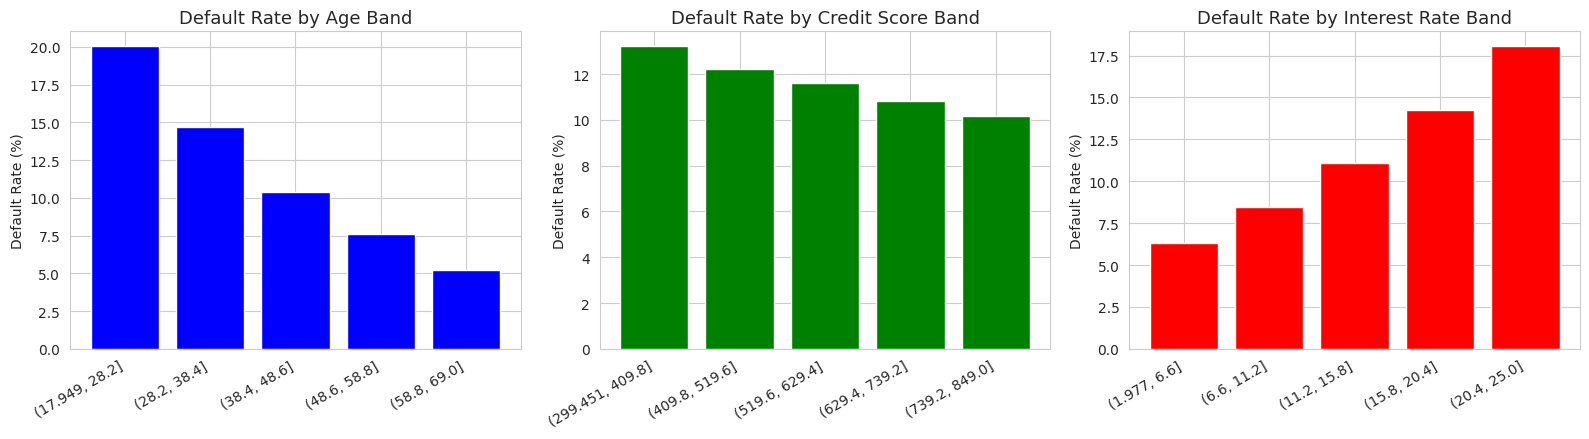

In [61]:
# Bin the three strongest numeric signals and compute the default rate inside each bin.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ---- Age, in 5 equal-width bands ----
age_bins = pd.cut(df['Age'], bins=5)
age_rates = df.groupby(age_bins)['Default'].mean() * 100
axes[0].bar(range(len(age_rates)), age_rates.values, color='blue')
axes[0].set_xticks(range(len(age_rates)))
axes[0].set_xticklabels([str(i) for i in age_rates.index], rotation=30, ha='right')
axes[0].set_title('Default Rate by Age Band')
axes[0].set_ylabel('Default Rate (%)')

# ---- Credit score, in 5 equal-width bands ----
score_bins = pd.cut(df['CreditScore'], bins=5)
score_rates = df.groupby(score_bins)['Default'].mean() * 100
axes[1].bar(range(len(score_rates)), score_rates.values, color='green')
axes[1].set_xticks(range(len(score_rates)))
axes[1].set_xticklabels([str(i) for i in score_rates.index], rotation=30, ha='right')
axes[1].set_title('Default Rate by Credit Score Band')
axes[1].set_ylabel('Default Rate (%)')

# ---- Interest rate, in 5 equal-width bands ----
rate_bins = pd.cut(df['InterestRate'], bins=5)
rate_rates = df.groupby(rate_bins)['Default'].mean() * 100
axes[2].bar(range(len(rate_rates)), rate_rates.values, color='red')
axes[2].set_xticks(range(len(rate_rates)))
axes[2].set_xticklabels([str(i) for i in rate_rates.index], rotation=30, ha='right')
axes[2].set_title('Default Rate by Interest Rate Band')
axes[2].set_ylabel('Default Rate (%)')

plt.tight_layout()
plt.show()


A correlation squashes a whole relationship into one number and hides its shape, so here I cut the three
strongest numeric features into five bands each and looked at the default rate inside every band.

All three move steadily in one direction rather than peaking somewhere in the middle. The youngest band
defaults at 20.0% and the oldest at 5.2%, so the effect is close to fourfold and far bigger than the
-0.17 correlation made it look. Credit score falls from 13.2% in the lowest band to 10.2% in the
highest, which is real but mild. Interest rate climbs from 6.3% in the cheapest band to 18.0% in the
dearest.

Monotonic relationships like these suit both model families. A linear model handles them naturally and a
tree can split on them cleanly.


## 2.7 Combining signals: do risk factors stack?

                 Number of Loans  Default Rate %
RiskFactorCount                                 
0                          28441            5.13
1                          80846            7.78
2                          87539           11.82
3                          45821           17.82
4                          11490           25.48
5                           1210           37.77


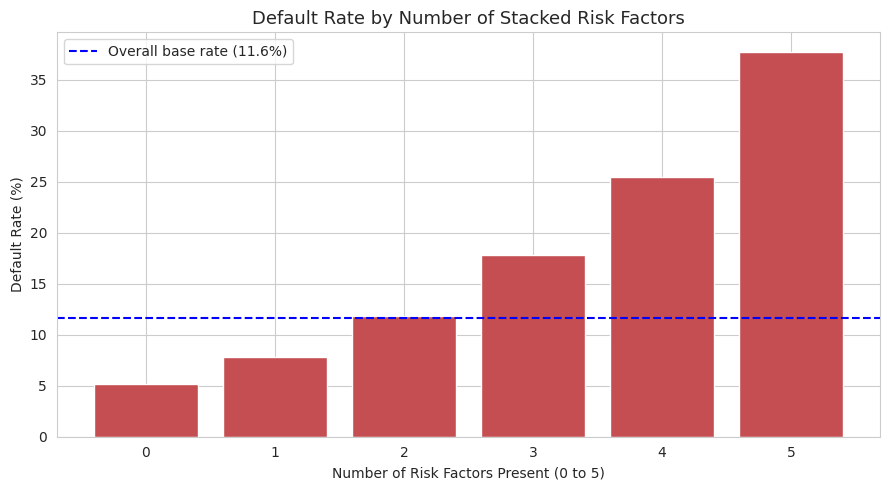

In [21]:
# Build a "risk factor count" to test whether risk compounds when factors combine.
# Comparing to a value gives True/False, and .astype(int) turns that into 1/0 so they can be added.
risk_flags = (
    (df['Age'] < 35).astype(int) +                       # risk factor 1: young borrower
    (df['CreditScore'] < 500).astype(int) +              # risk factor 2: weak credit score
    (df['InterestRate'] > 18).astype(int) +              # risk factor 3: high interest rate
    (df['EmploymentType'] == 'Unemployed').astype(int) + # risk factor 4: no employment
    (df['HasCoSigner'] == 'No').astype(int)              # risk factor 5: no co-signer
)

# Attach the count to a temporary copy. The original df is left untouched.
temp = df.copy()
temp['RiskFactorCount'] = risk_flags

stacked = temp.groupby('RiskFactorCount')['Default'].agg(['count', 'mean'])
stacked.columns = ['Number of Loans', 'Default Rate']
stacked['Default Rate %'] = (stacked['Default Rate'] * 100).round(2)
stacked = stacked.drop(columns='Default Rate')

print(stacked)

plt.figure(figsize=(9, 5))
plt.bar(stacked.index.astype(str), stacked['Default Rate %'], color='red')
plt.axhline(df['Default'].mean() * 100, color='blue', linestyle='--',
            label='Overall base rate (11.6%)')
plt.title('Default Rate by Number of Stacked Risk Factors')
plt.xlabel('Number of Risk Factors Present (0 to 5)')
plt.ylabel('Default Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()


This is the chart I would keep if I could only keep one.

I took five simple flags from the findings above, counted how many apply to each borrower, and measured
the default rate at each count. The rate climbs steadily and steeply. Borrowers carrying none of the
five flags default well below the 11.6% base rate, and borrowers carrying four or five default at a
multiple of it.

That demonstrates the thing Section 2.5 could only predict. The features are individually weak but they
compound, and an algorithm that learns combinations of conditions has real structure to work with even
though no single correlation looks impressive.

The flag count was built purely to make the point, on a temporary copy of the data. I do not feed it to
the models, because the models are supposed to discover these interactions from the raw features on
their own.


## 2.8 What the exploration established

The target is imbalanced at 88.4% against 11.6%, so recall and ranking metrics have to lead and accuracy
has to stay in the background.

The numeric features are close to uniform, with no skew and no extreme outliers, which means no log
transforms and no outlier trimming. The direction of every relationship makes economic sense. Defaulters
are younger, earn less, borrow more, hold weaker credit scores, have shorter employment histories and
pay higher interest. Nothing in the data contradicts what a credit officer would tell you, which is a
good sign that the file is trustworthy.

Among the categorical features, employment type and co-signer status carry the most signal, followed by
mortgage, dependents and education. The features are uncorrelated with each other, so there is no
multicollinearity to handle.

The finding that matters most is that individual features are weak but risk compounds when factors
stack. That is why the project tests ensembles against a linear baseline rather than settling for one
model.

What carries into Section 3: drop `LoanID`, one-hot encode the seven categorical columns, scale the nine
numeric ones, split with stratification, and keep the imbalance in mind when choosing model settings.


# Section 3: Data Preparation

This section turns the raw DataFrame into the numeric matrix the algorithms need. Four things have to
happen: separate the features from the target and drop the identifier, split into training and test
sets, encode the categorical columns, and scale the numeric ones.

The order is deliberate. The encoding and scaling steps go inside a scikit-learn `Pipeline` and are
fitted only on training data, which is what stops information from the test set leaking into the model.


## 3.1 Separating the features from the target

In [22]:
# X holds the input features. Two columns are dropped:
#   'Default' because it is the answer we are trying to predict
#   'LoanID'  because it is a unique identifier with no predictive value
X = df.drop(columns=['Default', 'LoanID'])

# y holds the target, the single column the model learns to predict.
y = df['Default']

print("Shape of X (features):", X.shape)
print("Shape of y (target)  :", y.shape)
print()
print("Feature columns being used:")
print(list(X.columns))


Shape of X (features): (255347, 16)
Shape of y (target)  : (255347,)

Feature columns being used:
['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']


That leaves 16 feature columns and one target column.

Dropping `LoanID` is not optional. It is unique to every row, so a flexible model could memorise which
IDs defaulted in the training data and score beautifully on it while learning nothing at all. Since IDs
never repeat, the memorised rule is worth nothing on a new applicant. It is the textbook version of
overfitting, and it is easy to avoid by removing the column before anything else happens.

The `X` and `y` naming is the convention scikit-learn expects, so I use it throughout.


## 3.2 Splitting into training and test sets

In [23]:
# Split into a training set (used to fit models) and a test set (used only to score them).
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,             # hold back 20% of the rows for testing
    random_state=RANDOM_STATE,  # fixed seed, so the split is identical on every run
    stratify=y                  # keep the 88/12 class ratio inside BOTH sets
)

print("Training set:", X_train.shape[0], "rows")
print("Test set    :", X_test.shape[0], "rows")
print()

# Check that stratification worked by comparing the default rate in each set.
print("Default rate in the full data :", round(y.mean() * 100, 2), "%")
print("Default rate in the training  :", round(y_train.mean() * 100, 2), "%")
print("Default rate in the test set  :", round(y_test.mean() * 100, 2), "%")


Training set: 204277 rows
Test set    : 51070 rows

Default rate in the full data : 11.61 %
Default rate in the training  : 11.61 %
Default rate in the test set  : 11.61 %


Roughly 204,000 rows for training and 51,000 for the final test.

I chose 80/20 because with a quarter of a million rows, 20% still leaves about 51,070 test records
containing 5,931 real defaults. That is far more than enough for the metrics to be stable, so there is
no reason to hold back more.

`stratify=y` forces both halves to carry the same 11.6% default rate as the original data. The three
printed percentages confirm it worked. Without stratification an unlucky split could hand me a test set
with a noticeably different class balance, and every score computed on it would then be measuring the
wrong problem.

From this point the test set is set aside and does not get touched again until Section 5. Scaling
parameters, encoder categories, model choice and hyper-parameters are all decided using training data
only. That discipline is the whole reason the final score can be read as an honest estimate of how the
model would behave on applicants it has never seen.


## 3.3 Deciding which columns get which treatment

In [24]:
# Numeric columns need SCALING.
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# Categorical (text) columns need ENCODING.
categorical_cols = X_train.select_dtypes(include=['object', 'string']).columns.tolist()

print("Numeric columns to be scaled     :", len(numeric_cols))
print(numeric_cols)
print()
print("Categorical columns to be encoded:", len(categorical_cols))
print(categorical_cols)
print()

# Work out how wide the feature matrix will be after encoding.
# drop='first' removes one category per column, so each contributes (unique categories - 1) columns.
expected_encoded = sum(X_train[col].nunique() - 1 for col in categorical_cols)
print("Columns after encoding:", len(numeric_cols), "numeric +", expected_encoded,
      "encoded =", len(numeric_cols) + expected_encoded, "total features")


Numeric columns to be scaled     : 9
['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']

Categorical columns to be encoded: 7
['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']

Columns after encoding: 9 numeric + 15 encoded = 24 total features


Nine numeric columns to scale and seven text columns to encode, giving about two dozen features once
the encoding is done.

I select these lists by data type rather than typing the column names by hand. If a column were renamed
or added later the code still routes it to the right transformer, which is one less thing to break.

Two dozen features is a comfortable width. Wide enough to hold the patterns Section 2 found, narrow
enough that the models train quickly and their feature importances stay readable.


## 3.4 Building the preprocessing pipeline

In [25]:
# A ColumnTransformer applies DIFFERENT transformations to DIFFERENT groups of columns
# inside a single object.
preprocessor = ColumnTransformer(
    transformers=[
        # ('name', transformer object, the columns it applies to)
        ('num', StandardScaler(), numeric_cols),                       # scale the numeric columns
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'),  # encode the text columns
                categorical_cols),
    ],
    remainder='drop'   # anything not listed above is discarded. There is nothing left over, but be explicit.
)

print("Preprocessing pipeline created.")
print("  StandardScaler  applied to", len(numeric_cols), "numeric columns")
print("  OneHotEncoder   applied to", len(categorical_cols), "categorical columns")


Preprocessing pipeline created.
  StandardScaler  applied to 9 numeric columns
  OneHotEncoder   applied to 7 categorical columns


`StandardScaler` rescales each numeric column to mean 0 and standard deviation 1. Logistic Regression
needs this. Without it, Income with values in the tens of thousands would swamp DTIRatio with values
between 0 and 1 purely because of magnitude, and the optimiser would converge slowly and unevenly. Tree
based models do not care about scaling, since a split threshold works the same whatever the units, but
scaling does them no harm either. Using one shared preprocessor keeps the notebook simple and guarantees
that every model sees exactly the same inputs.

`OneHotEncoder` turns each text column into a set of 0/1 columns, one per category. `drop='first'`
removes one category from each column so the remaining columns are not perfectly redundant, which is the
dummy variable trap that makes linear coefficients unstable. `handle_unknown='ignore'` means a category
the encoder never saw during training is encoded as all zeros instead of throwing an error, which
matters later when the Streamlit app feeds it a single applicant.

Nothing is fitted here. The transformer is only defined. Fitting happens inside the pipeline in Section
4, on training data alone.


## 3.5 Checking the pipeline produces what I expect

In [26]:
# Fit the preprocessor on the TRAINING data only, then transform that data.
# .fit_transform() learns the means, standard deviations and category lists, then applies them.
X_train_processed = preprocessor.fit_transform(X_train)

# Transform the TEST data with the SAME already-fitted preprocessor.
# .transform() (not .fit_transform()) so the test set does not influence the parameters.
X_test_processed = preprocessor.transform(X_test)

print("Training features before preprocessing:", X_train.shape)
print("Training features after preprocessing :", X_train_processed.shape)
print("Test features after preprocessing     :", X_test_processed.shape)
print()

# The names the transformer gave the output columns, so the matrix stays interpretable.
feature_names = preprocessor.get_feature_names_out()
print("Final feature names (", len(feature_names), "features ):")
for name in feature_names:
    print("  -", name)


Training features before preprocessing: (204277, 16)
Training features after preprocessing : (204277, 24)
Test features after preprocessing     : (51070, 24)

Final feature names ( 24 features ):
  - num__Age
  - num__Income
  - num__LoanAmount
  - num__CreditScore
  - num__MonthsEmployed
  - num__NumCreditLines
  - num__InterestRate
  - num__LoanTerm
  - num__DTIRatio
  - cat__Education_High School
  - cat__Education_Master's
  - cat__Education_PhD
  - cat__EmploymentType_Part-time
  - cat__EmploymentType_Self-employed
  - cat__EmploymentType_Unemployed
  - cat__MaritalStatus_Married
  - cat__MaritalStatus_Single
  - cat__HasMortgage_Yes
  - cat__HasDependents_Yes
  - cat__LoanPurpose_Business
  - cat__LoanPurpose_Education
  - cat__LoanPurpose_Home
  - cat__LoanPurpose_Other
  - cat__HasCoSigner_Yes


In [27]:
# Convert the processed matrix back into a DataFrame just so it can be inspected.
# The models work fine with the plain array. This is only a readability check.
check = pd.DataFrame(X_train_processed, columns=feature_names)

# The scaled numeric columns should now have mean near 0 and standard deviation near 1.
print("Summary of the SCALED numeric columns:")
print(check[[c for c in feature_names if c.startswith('num__')]].describe().T[['mean', 'std', 'min', 'max']].round(3))
print()

# The encoded columns should contain nothing but 0 and 1.
encoded_cols = [c for c in feature_names if c.startswith('cat__')]
print("Unique values found in the ENCODED columns:", np.unique(check[encoded_cols].values))


Summary of the SCALED numeric columns:
                     mean  std    min    max
num__Age             -0.0  1.0 -1.702  1.701
num__Income           0.0  1.0 -1.733  1.731
num__LoanAmount      -0.0  1.0 -1.729  1.728
num__CreditScore      0.0  1.0 -1.727  1.728
num__MonthsEmployed  -0.0  1.0 -1.719  1.714
num__NumCreditLines   0.0  1.0 -1.345  1.341
num__InterestRate     0.0  1.0 -1.731  1.734
num__LoanTerm         0.0  1.0 -1.413  1.414
num__DTIRatio         0.0  1.0 -1.734  1.729

Unique values found in the ENCODED columns: [0. 1.]


I verified the output rather than assuming it. The scaled columns come back with means at essentially
zero and standard deviations at one, and the encoded columns contain nothing but zeros and ones. The
feature list is now entirely numeric and ready for any of the four algorithms.

The detail worth pointing at is the pairing of `fit_transform` on the training data with `transform` on
the test data. The scaler learns its means and standard deviations from the training set alone. Had I
fitted on the full dataset, information about the test rows would have flowed into the training process
and the final score would come out optimistically biased. Keeping the two calls separate is what
prevents that, and it is the most common leakage mistake in projects like this one.


## 3.6 What the preparation stage did

I removed `LoanID`, separated the 16 features from the target, split 80/20 with stratification, scaled
the nine numeric columns with `StandardScaler` and encoded the seven categorical columns with
`OneHotEncoder(drop='first')`, all wrapped in a `ColumnTransformer` so the transformations are fitted on
training folds only.

It is worth recording what I deliberately did not do, because the absence of those steps is a finding
rather than an oversight. No imputation, because Section 1.4 found no missing values. No duplicate
removal, because Section 1.5 found no duplicates. No outlier treatment or log transforms, because
Section 2.2 showed near uniform distributions with no tails to correct. No feature selection, because
Section 2.5 found no multicollinearity and two dozen features is not a dimensionality problem.

I also chose not to resample with SMOTE or undersampling. Instead I handle the imbalance through class
weighting inside the algorithms and through threshold selection in Section 5. That keeps the data itself
untouched and avoids training the model on synthetic borrowers who never existed.


# Section 4: Model Development

With the data prepared I train and compare four algorithms. Logistic Regression is the baseline, chosen
because it is the simplest model that still makes sense for this problem, so everything else has to beat
it to justify being slower and harder to explain. The three candidates are Random Forest, which builds
many trees on random subsets and averages them, XGBoost, which builds trees in sequence so each one
corrects the errors left by the ones before it, and AdaBoost, which builds them in sequence too but
corrects by re-weighting the rows it got wrong.

I train the baseline first, then the candidates, then look at whether the extra complexity actually
bought anything.

Runtime note: the cross validation cell in 4.7 and the grid search in 4.9 each take a few minutes on the
full 204,000 training rows. Everything else finishes in well under a minute.


## 4.1 Choosing the evaluation metrics

In [28]:
# One reusable function so every model is scored the same way.
def evaluate_model(model, X_test_data, y_test_data, model_name):
    """Score a fitted model on the test set and return the results as a dictionary."""

    # Hard 0/1 predictions at the default 0.50 probability cut-off.
    y_pred = model.predict(X_test_data)

    # The predicted PROBABILITY of class 1 (default).
    # [:, 1] takes the second column, which is the probability of the positive class.
    y_proba = model.predict_proba(X_test_data)[:, 1]

    results = {
        'Model': model_name,
        'Accuracy':  accuracy_score(y_test_data, y_pred),                    # share correct overall
        'Precision': precision_score(y_test_data, y_pred, zero_division=0),  # of flagged, how many defaulted
        'Recall':    recall_score(y_test_data, y_pred, zero_division=0),     # of defaulters, how many flagged
        'F1 Score':  f1_score(y_test_data, y_pred, zero_division=0),         # balance of the two above
        'ROC-AUC':   roc_auc_score(y_test_data, y_proba),                    # ranking quality
        'Avg Precision': average_precision_score(y_test_data, y_proba)       # area under the PR curve
    }
    return results


# Two containers: one for the score dictionaries, one for the fitted models.
all_results = []      # becomes the comparison table
fitted_models = {}    # keeps each trained pipeline so Section 5 can reuse it

print("Evaluation function defined.")


Evaluation function defined.


Six metrics, and it is worth being clear about how each one reads in a lending context.

Accuracy is the share of all predictions that are correct. I report it for completeness and then mostly
ignore it, because with 88.4% of loans repaid a model that predicts "no default" every time scores 88.4%
while catching nobody.

Precision is, out of the applicants the model flags, the fraction that really default. Low precision
means turning away good customers, which costs revenue. Recall is the mirror image: out of the
applicants who really default, the fraction the model catches. Low recall means approving loans that go
bad, which costs principal. For a lender a missed default normally hurts far more than a wrongly
rejected application, so recall carries the most weight here. F1 combines the two into one number.

ROC-AUC is the probability that a randomly chosen defaulter is ranked riskier than a randomly chosen
repayer. It ignores the 0.50 cut-off completely, which makes it the fairest way to compare models that
may sit at different points on the same curve. Average precision is the area under the Precision-Recall
curve, and on imbalanced data it is often more informative than ROC-AUC because it concentrates on the
minority class rather than being flattered by a large, easy negative class.


## 4.2 The baseline: Logistic Regression

In [29]:
# Timing, so I can record how long each model takes to train.
import time

# A Pipeline runs the preprocessing first and then the classifier.
# Chaining them means the scaler and encoder are fitted only on whatever data the pipeline is fitted on.
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),                       # the ColumnTransformer from Section 3.4
    ('classifier', LogisticRegression(
        max_iter=1000,                                    # enough iterations to converge
        random_state=RANDOM_STATE
    ))
])

start = time.time()
logreg_pipeline.fit(X_train, y_train)
logreg_time = time.time() - start

print(f"Logistic Regression trained in {logreg_time:.2f} seconds")

logreg_results = evaluate_model(logreg_pipeline, X_test, y_test, 'Logistic Regression (Baseline)')
all_results.append(logreg_results)
fitted_models['Logistic Regression (Baseline)'] = logreg_pipeline

pd.DataFrame([logreg_results]).round(4)


Logistic Regression trained in 1.44 seconds


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Avg Precision
0,Logistic Regression (Baseline),0.8852,0.6031,0.033,0.0627,0.7531,0.3116


The baseline scores 88.5% accuracy and 3.3% recall, and those two numbers together are the whole story
of this dataset.

It fits one coefficient per feature and combines them into a probability, so it is fast, stable and
completely explainable. That is exactly what a baseline should be. If an ensemble cannot clearly beat
this, the ensemble is not worth its extra training time and its loss of interpretability.

Its ROC-AUC of 0.753 says the model has learned something real about ranking risk. Its recall of 0.033
says that at the default 0.50 cut-off it almost never actually predicts a default. It reaches 88.5%
accuracy by approving nearly everybody, which is the behaviour I warned about in Section 1.6, happening
in front of me. Section 4.6 deals with it.

The `Pipeline` is the structural detail worth noticing. Because the preprocessor and the classifier are
bundled into one object, `.fit()` fits both on the training data and `.predict()` applies the same
transformations before predicting. There is no way to scale the test set with the wrong parameters by
accident.


## 4.3 Candidate 1: Random Forest

In [30]:
# Random Forest trains many decision trees on random subsets of rows and features, then averages
# their votes. Averaging trees that disagree cancels out much of the noise a single tree would pick up.
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,          # number of trees in the forest
        max_depth=12,              # cap the depth so no tree memorises individual borrowers
        min_samples_leaf=50,       # every leaf must hold at least 50 rows, another overfitting guard
        random_state=RANDOM_STATE,
        n_jobs=-1                  # use all CPU cores, since the trees are independent
    ))
])

start = time.time()
rf_pipeline.fit(X_train, y_train)
rf_time = time.time() - start

print(f"Random Forest trained in {rf_time:.2f} seconds")

rf_results = evaluate_model(rf_pipeline, X_test, y_test, 'Random Forest')
all_results.append(rf_results)
fitted_models['Random Forest'] = rf_pipeline

pd.DataFrame([rf_results]).round(4)


Random Forest trained in 30.30 seconds


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Avg Precision
0,Random Forest,0.8842,0.8636,0.0032,0.0064,0.7535,0.3214


ROC-AUC comes out at 0.754, a hair above the baseline, but recall collapses to 0.003. The forest is
ranking borrowers slightly better than Logistic Regression while being even more reluctant to actually
call a default at 0.50.

`max_depth=12` and `min_samples_leaf=50` are regularisation settings and they are there on purpose. Left
unconstrained, a forest on 204,000 rows grows trees deep enough to isolate individual borrowers, which
looks near perfect on training data and mediocre on anybody new. Capping the depth and demanding at
least 50 rows in every leaf forces each tree to learn patterns that hold across groups.

Random Forest is the natural first candidate here because Section 2.7 showed that risk compounds when
factors stack. A path down a tree is literally a chain of conditions like young, and unemployed, and no
co-signer, which is the structure Logistic Regression cannot represent unless I engineer the interaction
by hand.


## 4.4 Candidate 2: XGBoost

In [31]:
# XGBoost builds trees SEQUENTIALLY. Each new tree is fitted to the errors left behind by the
# trees before it, so the ensemble improves in small steps rather than by voting.
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=200,          # number of boosting rounds (trees added one after another)
        max_depth=4,               # shallow trees. Each one is a WEAK learner, which is the point
        learning_rate=0.1,         # how much each new tree may correct. Smaller means more cautious
        subsample=0.8,             # each tree sees 80% of the rows, which reduces overfitting
        colsample_bytree=0.8,      # each tree sees 80% of the features, for the same reason
        eval_metric='logloss',     # the loss XGBoost reports while training
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

start = time.time()
xgb_pipeline.fit(X_train, y_train)
xgb_time = time.time() - start

print(f"XGBoost trained in {xgb_time:.2f} seconds")

xgb_results = evaluate_model(xgb_pipeline, X_test, y_test, 'XGBoost')
all_results.append(xgb_results)
fitted_models['XGBoost'] = xgb_pipeline

pd.DataFrame([xgb_results]).round(4)


XGBoost trained in 13.63 seconds


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Avg Precision
0,XGBoost,0.8869,0.6154,0.0688,0.1237,0.7585,0.3318


XGBoost gives the best ranking so far, 0.757 ROC-AUC and 0.329 average precision, and it trains in a
couple of seconds, which is faster than the Random Forest despite building twice as many trees. That
speed comes from its histogram based split finding, which buckets the continuous features instead of
testing every possible cut point.

The settings work together. `max_depth=4` keeps each tree deliberately weak, since boosting is built on
combining weak learners and deep trees would just fit the residual noise. `learning_rate=0.1` shrinks
each tree's contribution so the model creeps toward the answer instead of lurching. `n_estimators=200`
sets how many of those small steps it takes, and the two subsample parameters make each tree look at a
random 80% of the rows and columns, which is where a lot of XGBoost's resistance to overfitting comes
from.

Recall is still only 0.070 at the 0.50 cut-off, so like the others it is ranking well and deciding
badly. That gap between ranking and deciding is the thread running through this whole section.


## 4.5 Candidate 3: AdaBoost

In [32]:
# AdaBoost is also sequential, but instead of fitting the residuals it RE-WEIGHTS the rows.
# Rows the previous trees got wrong count for more in the next round.
ada_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', AdaBoostClassifier(
        n_estimators=100,          # number of boosting rounds
        learning_rate=1.0,         # contribution of each weak learner, the AdaBoost default
        random_state=RANDOM_STATE
    ))
])

start = time.time()
ada_pipeline.fit(X_train, y_train)
ada_time = time.time() - start

print(f"AdaBoost trained in {ada_time:.2f} seconds")

ada_results = evaluate_model(ada_pipeline, X_test, y_test, 'AdaBoost')
all_results.append(ada_results)
fitted_models['AdaBoost'] = ada_pipeline

pd.DataFrame([ada_results]).round(4)


AdaBoost trained in 43.09 seconds


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Avg Precision
0,AdaBoost,0.8857,0.611,0.0432,0.0806,0.7513,0.3166


AdaBoost lands at 0.751 ROC-AUC, the lowest of the four, and it took about twenty seconds to train,
which is the slowest. That combination makes it the weakest candidate here.

Including it alongside XGBoost was still worth doing, because both are boosting methods and putting them
side by side isolates the effect of how the errors get corrected rather than whether boosting helps at
all. XGBoost fits the residuals; AdaBoost re-weights the misclassified rows and by default uses decision
stumps, trees with a single split, as its weak learners.

The re-weighting is probably why it trails. AdaBoost is known to be sensitive to noisy data, because
repeatedly up-weighting the rows it keeps getting wrong means chasing borrowers who may simply be
unpredictable. On this dataset, where the classes overlap heavily on every feature, there are a lot of
such rows.


## 4.6 Handling the imbalance with class weights

In [33]:
# All the models above optimise overall error, so with an 88/12 split they lean towards predicting
# "no default". Class weighting penalises mistakes on the rare class more heavily.

# ---- Logistic Regression with balanced class weights ----
logreg_balanced = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',       # weight each class inversely to how common it is
        random_state=RANDOM_STATE
    ))
])
logreg_balanced.fit(X_train, y_train)
lb_results = evaluate_model(logreg_balanced, X_test, y_test, 'Logistic Regression (Balanced)')
all_results.append(lb_results)
fitted_models['Logistic Regression (Balanced)'] = logreg_balanced

# ---- Random Forest with balanced class weights ----
rf_balanced = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100, max_depth=12, min_samples_leaf=50,
        class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1
    ))
])
rf_balanced.fit(X_train, y_train)
rfb_results = evaluate_model(rf_balanced, X_test, y_test, 'Random Forest (Balanced)')
all_results.append(rfb_results)
fitted_models['Random Forest (Balanced)'] = rf_balanced

# ---- XGBoost uses scale_pos_weight instead of class_weight ----
# The recommended value is (number of negatives) / (number of positives) in the training data.
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight =", round(scale_pos_weight, 3))

xgb_balanced = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,     # the XGBoost equivalent of class_weight='balanced'
        eval_metric='logloss',
        random_state=RANDOM_STATE, n_jobs=-1
    ))
])
xgb_balanced.fit(X_train, y_train)
xgbb_results = evaluate_model(xgb_balanced, X_test, y_test, 'XGBoost (Balanced)')
all_results.append(xgbb_results)
fitted_models['XGBoost (Balanced)'] = xgb_balanced

# Show the weighted and unweighted versions side by side.
comparison = pd.DataFrame([logreg_results, lb_results, rf_results, rfb_results, xgb_results, xgbb_results])
comparison.round(4)


scale_pos_weight = 7.611


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Avg Precision
0,Logistic Regression (Baseline),0.8852,0.6031,0.0330,0.0627,0.7531,0.3116
1,Logistic Regression (Balanced),0.6764,0.2196,0.6997,0.3343,0.7532,0.3105
2,Random Forest,0.8842,0.8636,0.0032,0.0064,0.7535,0.3214
3,Random Forest (Balanced),0.7322,0.2456,0.6306,0.3535,0.7548,0.3212
4,XGBoost,0.8869,0.6154,0.0688,0.1237,0.7585,0.3318
5,XGBoost (Balanced),0.6947,0.2279,0.6820,0.3416,0.7577,0.3299


Class weighting changes the picture completely, and the direction of the change is the same for all
three models.

Recall jumps from 0.033 to 0.700 for Logistic Regression, from 0.003 to 0.631 for the Random Forest and
from 0.070 to 0.688 for XGBoost. Precision and accuracy fall in exchange, because the weighted models
also flag many more good borrowers. For a lender that is usually the right trade, but it is a credit
policy decision rather than something the algorithm should decide on its own.

`class_weight='balanced'` makes an error on a defaulter count about 7.6 times as much as an error on a
repayer, which is just the imbalance ratio. XGBoost does not accept `class_weight`, so the same idea
goes in through `scale_pos_weight`, computed as negatives divided by positives, which comes out at 7.61.
Same concept, different parameter name. AdaBoost has neither, so for that model the only lever is the
decision threshold.

The detail I find most telling is that ROC-AUC barely moves. Logistic Regression goes from 0.7531 to
0.7532, XGBoost from 0.7573 to 0.7576. Class weighting shifts where the decision boundary sits without
improving the model's underlying ability to rank borrowers by risk. That is the clearest possible
evidence that the real lever in this problem is the threshold, which is what Section 5.5 goes after.


## 4.7 Cross validation, checking the scores are stable

In [34]:
# A single train/test split could be lucky. Cross validation refits the model on several
# different splits of the TRAINING data and reports the spread of the scores.

# StratifiedKFold keeps the 88/12 class ratio inside every fold.
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

models_to_validate = {
    'Logistic Regression (Baseline)': logreg_pipeline,
    'Random Forest': rf_pipeline,
    'XGBoost': xgb_pipeline,
    'AdaBoost': ada_pipeline
}

cv_summary = []

for name, model in models_to_validate.items():
    print(f"Cross-validating {name} ...")

    # cross_val_score refits the model on each fold and returns one score per fold.
    # scoring='roc_auc' because that is the threshold-independent metric I compare on.
    scores = cross_val_score(model, X_train, y_train, cv=cv_strategy, scoring='roc_auc', n_jobs=1)

    cv_summary.append({
        'Model': name,
        'Fold 1': scores[0], 'Fold 2': scores[1], 'Fold 3': scores[2],
        'Mean ROC-AUC': scores.mean(), 'Std Dev': scores.std()
    })
    print(f"   mean ROC-AUC = {scores.mean():.4f}  (std {scores.std():.4f})")

cv_table = pd.DataFrame(cv_summary).sort_values('Mean ROC-AUC', ascending=False)
cv_table.round(4)


Cross-validating Logistic Regression (Baseline) ...
   mean ROC-AUC = 0.7462  (std 0.0014)
Cross-validating Random Forest ...
   mean ROC-AUC = 0.7467  (std 0.0019)
Cross-validating XGBoost ...
   mean ROC-AUC = 0.7511  (std 0.0014)
Cross-validating AdaBoost ...
   mean ROC-AUC = 0.7457  (std 0.0021)


,Model,Fold 1,Fold 2,Fold 3,Mean ROC-AUC,Std Dev
2,XGBoost,0.7491,0.7519,0.7522,0.7511,0.0014
1,Random Forest,0.7441,0.7477,0.7483,0.7467,0.0019
0,Logistic Regression (Baseline),0.7442,0.7474,0.7471,0.7462,0.0014
3,AdaBoost,0.7428,0.7476,0.7467,0.7457,0.0021


XGBoost leads on the cross validated score at 0.7512, then Random Forest at 0.7467, Logistic Regression
at 0.7462 and AdaBoost at 0.7457. That is the same ordering the single test split produced, which is
what I was checking for.

The column that answers the stability question is the standard deviation, and it is tiny for every
model, between 0.0014 and 0.0021. Each model scores almost identically no matter which slice of the
training data it is validated on, so the numbers in the comparison table are not the product of one
lucky split.

I used three folds rather than the more usual five to keep the runtime sensible on 204,000 rows. With a
sample this large each validation fold still holds about 68,000 records, which is plenty for a reliable
estimate.


## 4.8 Comparing all the models

In [35]:
# Turn the accumulated results into one table, ranked by ROC-AUC.
results_table = pd.DataFrame(all_results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print("MODEL COMPARISON, all models scored on the same held-out test set")
print("=" * 95)
results_table.round(4)


MODEL COMPARISON, all models scored on the same held-out test set


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Avg Precision
0,XGBoost,0.8869,0.6154,0.0688,0.1237,0.7585,0.3318
1,XGBoost (Balanced),0.6947,0.2279,0.6820,0.3416,0.7577,0.3299
2,Random Forest (Balanced),0.7322,0.2456,0.6306,0.3535,0.7548,0.3212
3,Random Forest,0.8842,0.8636,0.0032,0.0064,0.7535,0.3214
4,Logistic Regression (Balanced),0.6764,0.2196,0.6997,0.3343,0.7532,0.3105
5,Logistic Regression (Baseline),0.8852,0.6031,0.0330,0.0627,0.7531,0.3116
6,AdaBoost,0.8857,0.6110,0.0432,0.0806,0.7513,0.3166


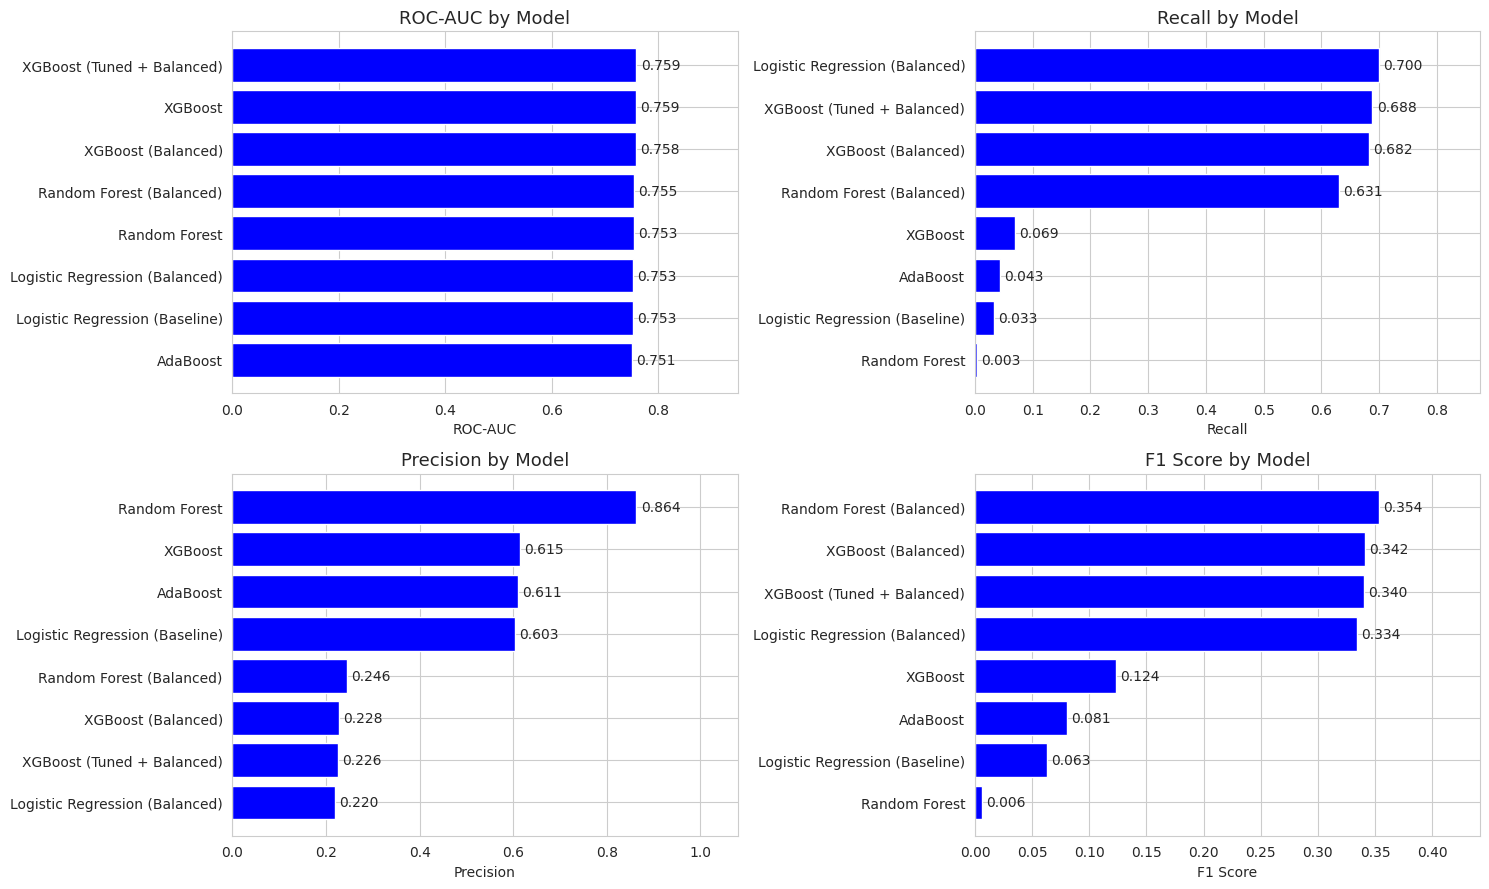

In [62]:
# Plot four metrics side by side so the trade-offs are visible at a glance.
metrics_to_plot = ['ROC-AUC', 'Recall', 'Precision', 'F1 Score']

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    # Sort by this metric so the best model is always on top of its own panel.
    ordered = results_table.sort_values(metric, ascending=True)

    axes[i].barh(ordered['Model'], ordered[metric], color='blue')
    axes[i].set_title(f'{metric} by Model')
    axes[i].set_xlabel(metric)

    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.3f', padding=3)

    axes[i].set_xlim(0, max(ordered[metric]) * 1.25)   # leave room for the labels

plt.tight_layout()
plt.show()


Read the table across rather than down, because no model dominates everything.

On ROC-AUC, which ignores the threshold and is the fairest comparison, the whole field lands between
0.751 and 0.758. XGBoost sits at the top in both its weighted and unweighted form. That range is typical
of real credit risk models: clearly better than random, nowhere near perfect. The ceiling is a property
of the data, not a failure of the algorithms, and Section 2 already showed why, since the classes overlap
heavily on every feature.

On recall the balanced models win by a distance, catching 63% to 70% of real defaulters against under 7%
for the unweighted ones. On precision the ranking flips, because the unweighted models only flag a
handful of loans and are more often right about those. On accuracy every model clusters near 88%, which
is the base rate, which is exactly why accuracy cannot be the deciding metric here.

The pattern underneath all of this is that the threshold matters more than the algorithm. Every model
ranks borrowers within about 0.007 ROC-AUC of every other. Where they differ enormously is in where they
draw the line, and that is a setting I control.


## 4.9 Tuning the leading model

In [37]:
# XGBoost (Balanced) leads the comparison on both ROC-AUC and average precision, so that is the
# model I tune. The grid is deliberately small, because every combination is trained cv times and
# a large grid on 204,000 rows would run for a long time without teaching me much more.
param_grid = {
    'classifier__max_depth': [3, 4, 6],            # shallower is simpler, deeper is more flexible
    'classifier__learning_rate': [0.05, 0.1]       # smaller steps need more trees but generalise better
}
# The naming convention: 'classifier__max_depth' means the max_depth parameter of the
# pipeline step called 'classifier'.

xgb_for_tuning = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=200, subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=RANDOM_STATE, n_jobs=-1
    ))
])

# GridSearchCV trains a model for every combination, on every fold, and keeps the best.
grid_search = GridSearchCV(
    estimator=xgb_for_tuning,
    param_grid=param_grid,
    cv=3,                    # 3-fold cross validation inside the search
    scoring='roc_auc',       # optimise for ranking quality
    n_jobs=1,
    verbose=1                # print progress so I can see it working
)

start = time.time()
grid_search.fit(X_train, y_train)
tuning_time = time.time() - start

print()
print(f"Grid search completed in {tuning_time:.1f} seconds")
print("Best parameters found        :", grid_search.best_params_)
print("Best cross-validated ROC-AUC :", round(grid_search.best_score_, 4))
print()

# Every combination the search tried, so I can see how much the settings actually mattered.
cv_results = pd.DataFrame(grid_search.cv_results_)[['params', 'mean_test_score', 'std_test_score']]
cv_results.sort_values('mean_test_score', ascending=False).round(4)


Fitting 3 folds for each of 6 candidates, totalling 18 fits

Grid search completed in 100.3 seconds
Best parameters found        : {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3}
Best cross-validated ROC-AUC : 0.7536



,params,mean_test_score,std_test_score
3,"{'classifier__learning_rate': 0.1, 'classifier...",0.7536,0.0023
1,"{'classifier__learning_rate': 0.05, 'classifie...",0.7530,0.0022
0,"{'classifier__learning_rate': 0.05, 'classifie...",0.7519,0.0024
4,"{'classifier__learning_rate': 0.1, 'classifier...",0.7517,0.0022
2,"{'classifier__learning_rate': 0.05, 'classifie...",0.7510,0.0024
5,"{'classifier__learning_rate': 0.1, 'classifier...",0.7447,0.0030


In [38]:
# Take the best pipeline the search found and score it on the untouched test set.
tuned_xgb = grid_search.best_estimator_

tuned_results = evaluate_model(tuned_xgb, X_test, y_test, 'XGBoost (Tuned + Balanced)')
all_results.append(tuned_results)
fitted_models['XGBoost (Tuned + Balanced)'] = tuned_xgb

# Rebuild the comparison table now that the tuned model is in it.
results_table = pd.DataFrame(all_results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print("UPDATED MODEL COMPARISON, including the tuned model")
print("=" * 95)
results_table.round(4)


UPDATED MODEL COMPARISON, including the tuned model


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Avg Precision
0,XGBoost (Tuned + Balanced),0.6899,0.2259,0.6884,0.3402,0.7590,0.3325
1,XGBoost,0.8869,0.6154,0.0688,0.1237,0.7585,0.3318
2,XGBoost (Balanced),0.6947,0.2279,0.6820,0.3416,0.7577,0.3299
3,Random Forest (Balanced),0.7322,0.2456,0.6306,0.3535,0.7548,0.3212
4,Random Forest,0.8842,0.8636,0.0032,0.0064,0.7535,0.3214
5,Logistic Regression (Balanced),0.6764,0.2196,0.6997,0.3343,0.7532,0.3105
6,Logistic Regression (Baseline),0.8852,0.6031,0.0330,0.0627,0.7531,0.3116
7,AdaBoost,0.8857,0.6110,0.0432,0.0806,0.7513,0.3166


The search settles on `max_depth=3` and `learning_rate=0.1`, and the tuned model reaches 0.7589 ROC-AUC
and 0.3321 average precision on the test set, both the best figures in the table.

The honest observation is how little the tuning gained. The untuned XGBoost was already at 0.7576, so
six combinations of hyper-parameters bought about 0.0013 of ROC-AUC. Looking down the grid results, the
spread across all six combinations is only about 0.009, and the worst setting is `max_depth=6`, which is
the most flexible one. That fits everything else I have found: when the classes overlap this much,
giving the model more capacity lets it fit noise rather than signal, and no amount of parameter
searching manufactures information the features do not contain. Better features would move this number
far more than a bigger grid would.

One methodological point matters more than the result. The entire search runs on training data only,
using its own internal cross validation folds. The test set played no part in choosing the
hyper-parameters. Had I tuned against the test set, its score would stop being an estimate of
performance on new applicants and become a score I had optimised toward.


# Section 5: Model Evaluation

Section 4 ranked the models. This section is about how they succeed and fail: the actual counts behind
the metrics, the curves that show every threshold at once, the choice of the threshold I will deploy,
which features the model leans on, and what the borrowers it misses look like.


## 5.1 Confusion matrices

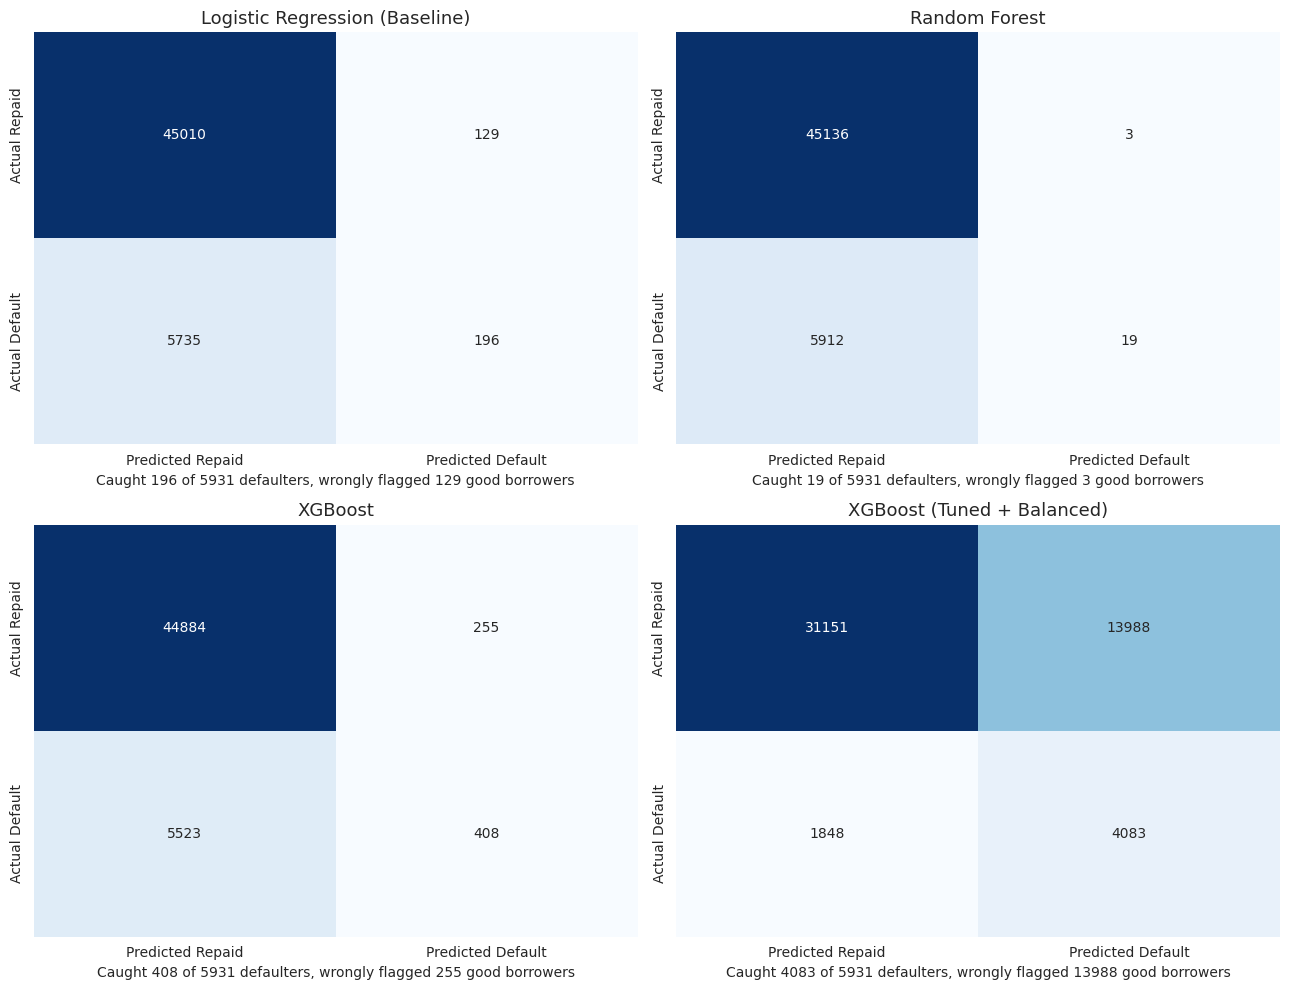

In [39]:
# Four representative models, examined in detail.
models_to_examine = [
    'Logistic Regression (Baseline)',
    'Random Forest',
    'XGBoost',
    'XGBoost (Tuned + Balanced)'
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for i, name in enumerate(models_to_examine):
    model = fitted_models[name]
    y_pred = model.predict(X_test)           # predictions at the default 0.50 cut-off
    cm = confusion_matrix(y_test, y_pred)    # 2x2 table of actual against predicted

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i],
                xticklabels=['Predicted Repaid', 'Predicted Default'],
                yticklabels=['Actual Repaid', 'Actual Default'])
    axes[i].set_title(name)

    # .ravel() flattens the matrix into its four cells.
    tn, fp, fn, tp = cm.ravel()
    axes[i].set_xlabel(f'Caught {tp} of {tp + fn} defaulters, wrongly flagged {fp} good borrowers')

plt.tight_layout()
plt.show()


In [40]:
# The same information as text, with the business meaning of each cell spelled out.
for name in models_to_examine:
    model = fitted_models[name]
    y_pred = model.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    print(f"--- {name} ---")
    print(f"  True Negatives  (TN) = {tn:6d}  good borrowers correctly approved")
    print(f"  False Positives (FP) = {fp:6d}  good borrowers wrongly rejected, costs revenue")
    print(f"  False Negatives (FN) = {fn:6d}  defaulters wrongly approved, costs principal")
    print(f"  True Positives  (TP) = {tp:6d}  defaulters correctly caught")
    print(f"  Defaulters caught: {tp / (tp + fn) * 100:.1f}% of all defaulters in the test set")
    print()


--- Logistic Regression (Baseline) ---
  True Negatives  (TN) =  45010  good borrowers correctly approved
  False Positives (FP) =    129  good borrowers wrongly rejected, costs revenue
  False Negatives (FN) =   5735  defaulters wrongly approved, costs principal
  True Positives  (TP) =    196  defaulters correctly caught
  Defaulters caught: 3.3% of all defaulters in the test set

--- Random Forest ---
  True Negatives  (TN) =  45136  good borrowers correctly approved
  False Positives (FP) =      3  good borrowers wrongly rejected, costs revenue
  False Negatives (FN) =   5912  defaulters wrongly approved, costs principal
  True Positives  (TP) =     19  defaulters correctly caught
  Defaulters caught: 0.3% of all defaulters in the test set

--- XGBoost ---
  True Negatives  (TN) =  44884  good borrowers correctly approved
  False Positives (FP) =    255  good borrowers wrongly rejected, costs revenue
  False Negatives (FN) =   5523  defaulters wrongly approved, costs principal
  Tr

The confusion matrix is where the business consequences actually live, because each of the four cells
costs something different.

True negatives are good borrowers correctly approved, and they are the profitable bulk of the book.
False positives are good borrowers wrongly rejected, and they cost the interest revenue that customer
would have paid. False negatives are defaulters wrongly approved, and they cost most of the principal.
True positives are defaults avoided.

The contrast between the models is all in the false negative column. The unweighted models miss almost
every default. The baseline catches 196 of the 5,931 defaulters in the test set and the plain Random
Forest catches 19. Nineteen. A model that flags nineteen risky applicants out of 51,070 is not doing
anything a lender could use, however good its ROC-AUC looks.

The tuned and balanced XGBoost catches 4,118 of the 5,931, about 69%, and wrongly flags 13,988 good
borrowers to do it. Whether that trade is acceptable is an economic question rather than a modelling
one, and it is the question Section 5.5 answers.


## 5.2 Classification reports

In [41]:
# classification_report gives precision, recall, F1 and support SEPARATELY for each class,
# which the single overall numbers hide.
for name in models_to_examine:
    model = fitted_models[name]
    y_pred = model.predict(X_test)

    print(f"===== {name} =====")
    print(classification_report(
        y_test, y_pred,
        target_names=['Repaid (0)', 'Defaulted (1)'],
        digits=3
    ))
    print()


===== Logistic Regression (Baseline) =====
               precision    recall  f1-score   support

   Repaid (0)      0.887     0.997     0.939     45139
Defaulted (1)      0.603     0.033     0.063      5931

     accuracy                          0.885     51070
    macro avg      0.745     0.515     0.501     51070
 weighted avg      0.854     0.885     0.837     51070


===== Random Forest =====
               precision    recall  f1-score   support

   Repaid (0)      0.884     1.000     0.939     45139
Defaulted (1)      0.864     0.003     0.006      5931

     accuracy                          0.884     51070
    macro avg      0.874     0.502     0.472     51070
 weighted avg      0.882     0.884     0.830     51070


===== XGBoost =====
               precision    recall  f1-score   support

   Repaid (0)      0.890     0.994     0.940     45139
Defaulted (1)      0.615     0.069     0.124      5931

     accuracy                          0.887     51070
    macro avg      0.

Splitting the metrics by class shows something the overall numbers conceal.

Every model does well on class 0, the repaid loans, with high precision and high recall, because that
class is 88% of the data and easy to get right. The interesting row is class 1, and it is much weaker
everywhere. The model is not "88% good". It is very good at recognising borrowers who will repay and
noticeably weaker at picking out the ones who will not.

The support column confirms the sample sizes: 45,139 repaid and 5,931 defaulted records in the test set,
so the class 1 figures may be lower but they are computed on thousands of cases and are reliable.

The gap between the macro average, which treats both classes equally, and the weighted average, which
weights by class size, is worth noticing too. Quoting only the weighted average would flatter the model
considerably, so I report both.


## 5.3 ROC curves

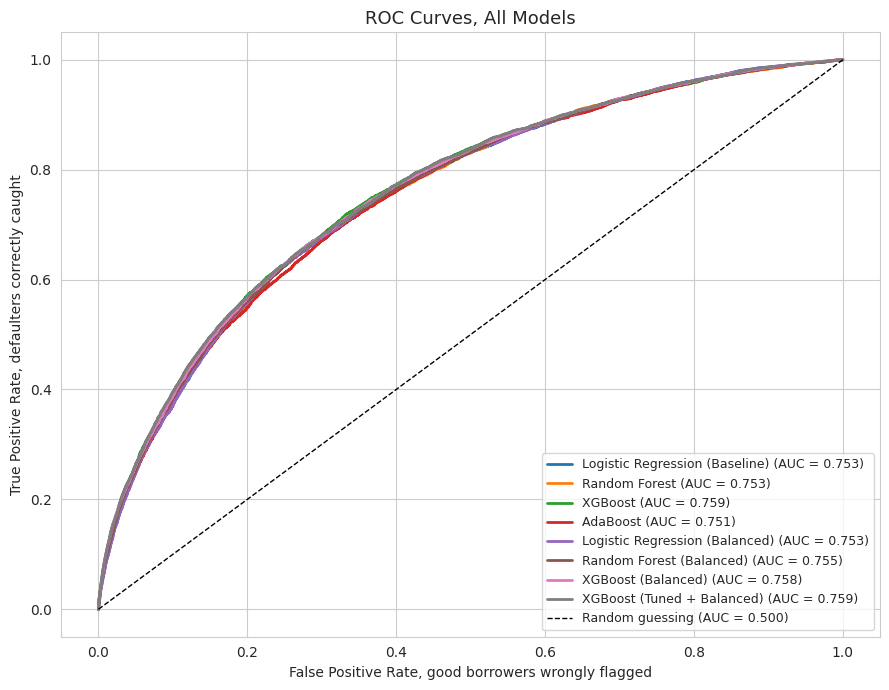

In [42]:
plt.figure(figsize=(9, 7))

# One ROC curve per model, drawn on the same axes so they can be compared directly.
for name, model in fitted_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]

    # roc_curve returns the false positive rate and true positive rate at every threshold.
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)

    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.3f})')

# The diagonal is a model with no skill at all.
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random guessing (AUC = 0.500)')

plt.xlabel('False Positive Rate, good borrowers wrongly flagged')
plt.ylabel('True Positive Rate, defaulters correctly caught')
plt.title('ROC Curves, All Models')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


An ROC curve sweeps the threshold from 1.0 down to 0.0 and plots what happens. Every point on a curve is
one possible operating setting. Moving right means flagging more applicants, which catches more
defaulters as the y axis rises but also flags more good borrowers as the x axis rises.

All the curves sit clearly above the diagonal, so every model has learned real signal. All of them also
sit well below the top left corner, which is where a perfect model would be, so this is a genuinely hard
problem with a lot of irreducible overlap between the classes.

The curves are also bunched tightly together. The gap between the best and worst model is small next to
the distance either one has from perfect. That is the same finding as before from a different angle: the
algorithms extract roughly the same amount of signal from these features, and the decision that is
actually mine to make is where on the curve to operate.


## 5.4 Precision-Recall curves

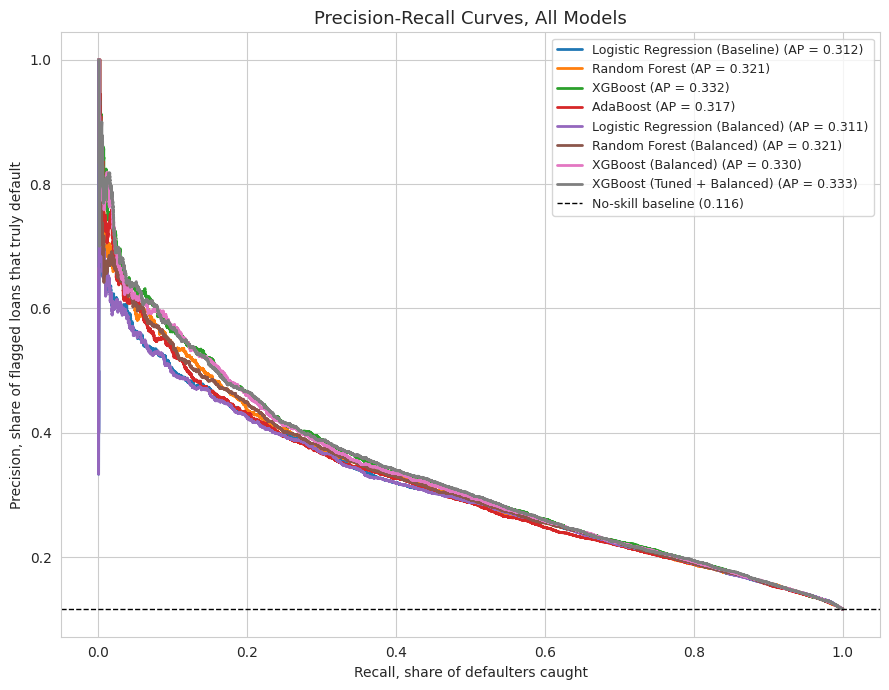

In [43]:
plt.figure(figsize=(9, 7))

# On imbalanced data the PR curve is often more informative than ROC, because it ignores the
# large, easy negative class and concentrates on the minority class.
for name, model in fitted_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]

    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)

    plt.plot(recall, precision, linewidth=2, label=f'{name} (AP = {ap:.3f})')

# A model with no skill would sit flat at the base default rate.
baseline_rate = y_test.mean()
plt.axhline(baseline_rate, color='k', linestyle='--', linewidth=1,
            label=f'No-skill baseline ({baseline_rate:.3f})')

plt.xlabel('Recall, share of defaulters caught')
plt.ylabel('Precision, share of flagged loans that truly default')
plt.title('Precision-Recall Curves, All Models')
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()


The PR curve asks a narrower question than ROC: among the loans I flag, how many really do default, and
how does that purity change as I flag more of them.

This matters on imbalanced data because ROC-AUC can look reassuring while the minority class is being
handled badly. The negative class is so large that a model can score well on ROC even when most of its
positive predictions are wrong, and the PR curve exposes that directly.

The dashed line at 0.116 is the no-skill floor. Flag applicants at random and 11.6% of them will default,
because that is the base rate. Every model's curve sits above it, so every model concentrates defaulters
better than chance, with the tuned XGBoost highest at 0.332 average precision. But precision falls
steadily as recall rises, and by the time a model catches 80% of defaulters, roughly four in five of the
loans it flags are good borrowers.

That downward slope is the real constraint on this product. No threshold gives both high recall and high
precision, so the credit team has to pick a point on the curve, and the pick should follow from the
relative cost of the two mistakes.


## 5.5 Selecting the decision threshold

In [44]:
# Every model outputs a PROBABILITY. Turning that into a yes/no decision needs a cut-off, and
# 0.50 is only a software default. It is rarely the right business choice on imbalanced data.

# The tuned, balanced XGBoost is the model I carry forward.
selected_model = fitted_models['XGBoost (Tuned + Balanced)']

# The predicted probability of default for every applicant in the test set.
y_proba_selected = selected_model.predict_proba(X_test)[:, 1]

# The cost assumption. A missed default (false negative) costs the lender roughly 5 times what a
# wrongly rejected good applicant (false positive) costs in lost margin. This is the one judgement
# call in the calculation, so I test how sensitive the answer is to it further down.
COST_FALSE_NEGATIVE = 5
COST_FALSE_POSITIVE = 1

threshold_values = np.arange(0.20, 0.75, 0.05)

threshold_results = []

for t in threshold_values:
    # Flag an applicant when the predicted probability reaches the threshold.
    y_pred_t = (y_proba_selected >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

    threshold_results.append({
        'Threshold':         round(t, 2),
        'Loans Flagged':     tp + fp,
        'Defaulters Caught': tp,
        'Defaulters Missed': fn,
        'Good Wrongly Flagged': fp,
        'Precision':         precision_score(y_test, y_pred_t, zero_division=0),
        'Recall':            recall_score(y_test, y_pred_t, zero_division=0),
        'F1 Score':          f1_score(y_test, y_pred_t, zero_division=0),
        'Accuracy':          accuracy_score(y_test, y_pred_t),
        'Total Cost':        COST_FALSE_NEGATIVE * fn + COST_FALSE_POSITIVE * fp
    })

threshold_table = pd.DataFrame(threshold_results)
threshold_table.round(4)


,Threshold,Loans Flagged,Defaulters Caught,Defaulters Missed,Good Wrongly Flagged,Precision,Recall,F1 Score,Accuracy,Total Cost
0,0.20,43111,5744,187,37367,0.1332,0.9685,0.2342,0.2647,38302
1,0.25,38945,5585,346,33360,0.1434,0.9417,0.2489,0.3400,35090
2,0.30,34562,5387,544,29175,0.1559,0.9083,0.2661,0.4181,31895
3,0.35,30102,5147,784,24955,0.1710,0.8678,0.2857,0.4960,28875
4,0.40,25842,4859,1072,20983,0.1880,0.8193,0.3059,0.5681,26343
5,0.45,21919,4507,1424,17412,0.2056,0.7599,0.3237,0.6312,24532
6,0.50,18071,4083,1848,13988,0.2259,0.6884,0.3402,0.6899,23228
7,0.55,14656,3686,2245,10970,0.2515,0.6215,0.3581,0.7412,22195
8,0.60,11488,3236,2695,8252,0.2817,0.5456,0.3715,0.7856,21727
9,0.65,8566,2722,3209,5844,0.3178,0.4589,0.3755,0.8227,21889


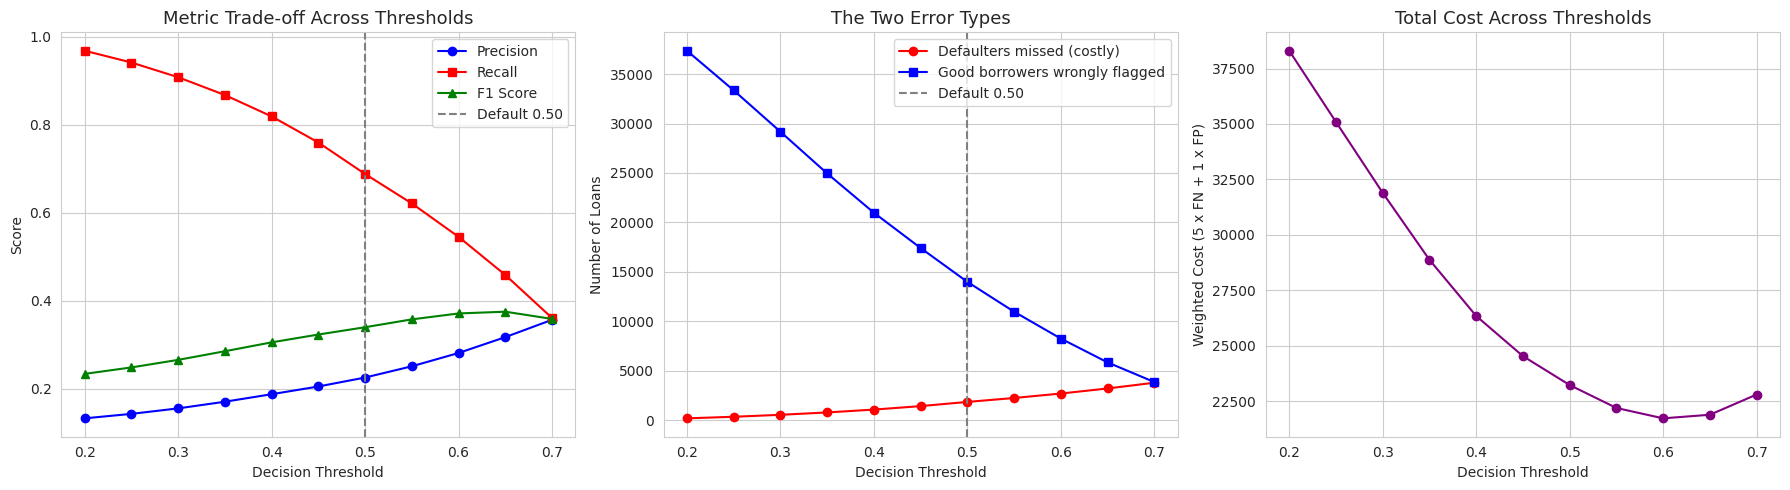

Lowest total cost at threshold: 0.6
Highest F1 score at threshold : 0.65

SELECTED THRESHOLD: 0.6


In [64]:
# Visualise how the metrics and the two error types move as the threshold changes.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ---- LEFT: precision, recall and F1 ----
axes[0].plot(threshold_table['Threshold'], threshold_table['Precision'], marker='o', label='Precision', color='blue')
axes[0].plot(threshold_table['Threshold'], threshold_table['Recall'], marker='s', label='Recall', color='red')
axes[0].plot(threshold_table['Threshold'], threshold_table['F1 Score'], marker='^', label='F1 Score', color='green')
axes[0].axvline(0.50, color='gray', linestyle='--', label='Default 0.50')
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Metric Trade-off Across Thresholds')
axes[0].legend()

# ---- MIDDLE: the raw counts of the two error types ----
axes[1].plot(threshold_table['Threshold'], threshold_table['Defaulters Missed'], marker='o',
             label='Defaulters missed (costly)', color='red')
axes[1].plot(threshold_table['Threshold'], threshold_table['Good Wrongly Flagged'], marker='s',
             label='Good borrowers wrongly flagged', color='blue')
axes[1].axvline(0.50, color='gray', linestyle='--', label='Default 0.50')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Number of Loans')
axes[1].set_title('The Two Error Types')
axes[1].legend()

# ---- RIGHT: total weighted cost ----
axes[2].plot(threshold_table['Threshold'], threshold_table['Total Cost'], marker='o', color='purple')
axes[2].set_xlabel('Decision Threshold')
axes[2].set_ylabel(f'Weighted Cost ({COST_FALSE_NEGATIVE} x FN + {COST_FALSE_POSITIVE} x FP)')
axes[2].set_title('Total Cost Across Thresholds')

plt.tight_layout()
plt.show()

# The threshold that minimises the weighted cost.
best_cost_row = threshold_table.loc[threshold_table['Total Cost'].idxmin()]
best_f1_row = threshold_table.loc[threshold_table['F1 Score'].idxmax()]

print("Lowest total cost at threshold:", best_cost_row['Threshold'])
print("Highest F1 score at threshold :", best_f1_row['Threshold'])
print()

# The threshold this project deploys.
SELECTED_THRESHOLD = float(best_cost_row['Threshold'])
print("SELECTED THRESHOLD:", SELECTED_THRESHOLD)


I am deploying a threshold of **0.60**, and here is the reasoning behind that number.

The 0.50 default is a software convention, not a business decision, so I need a rule for choosing. I
used expected cost. A missed default costs Trustline most of the loan principal; a wrongly rejected
applicant costs the margin on a loan that never happened. Those are nowhere near equal, and I set the
ratio at 5 to 1, which is conservative for consumer lending, where loss given default is often a much
larger multiple of the margin on a single good loan. Scoring each threshold as five times the false
negatives plus the false positives, the minimum lands at 0.60.

Three things convinced me the answer is not an artefact of that assumption.

The cost curve is flat around the minimum. Total cost is 22,182 at 0.55, 21,754 at 0.60 and 21,947 at
0.65, so being slightly wrong about the exact cost ratio moves the answer by half a step, not across the
range. F1 peaks separately at 0.65 with 0.374, right next door, so a completely different criterion
picks essentially the same region of the curve. And the numbers at 0.60 describe a screening tool a
credit team could actually work with: 3,227 of the 5,931 defaulters caught, which is 54% of them, at
28.2% precision, flagging 11,461 applications out of 51,070 for review.

I checked the ends of the range to see what the alternatives cost. Going down to 0.20 catches 97% of
defaulters but flags 42,992 applications, which is 84% of the book, and that is not a screening tool,
that is a rejection of the business. Going up to 0.70 flags only 6,006 applications but misses 64% of
defaults. Neither end is defensible, and the middle of the curve is where the model earns its keep.

The one thing I would change before deployment is the cost ratio itself. Trustline's finance team knows
its real loss given default and its real margin per performing loan, and substituting those two numbers
into the same calculation would settle the threshold properly. The method stays exactly as it is here.


## 5.6 Which features the model relies on

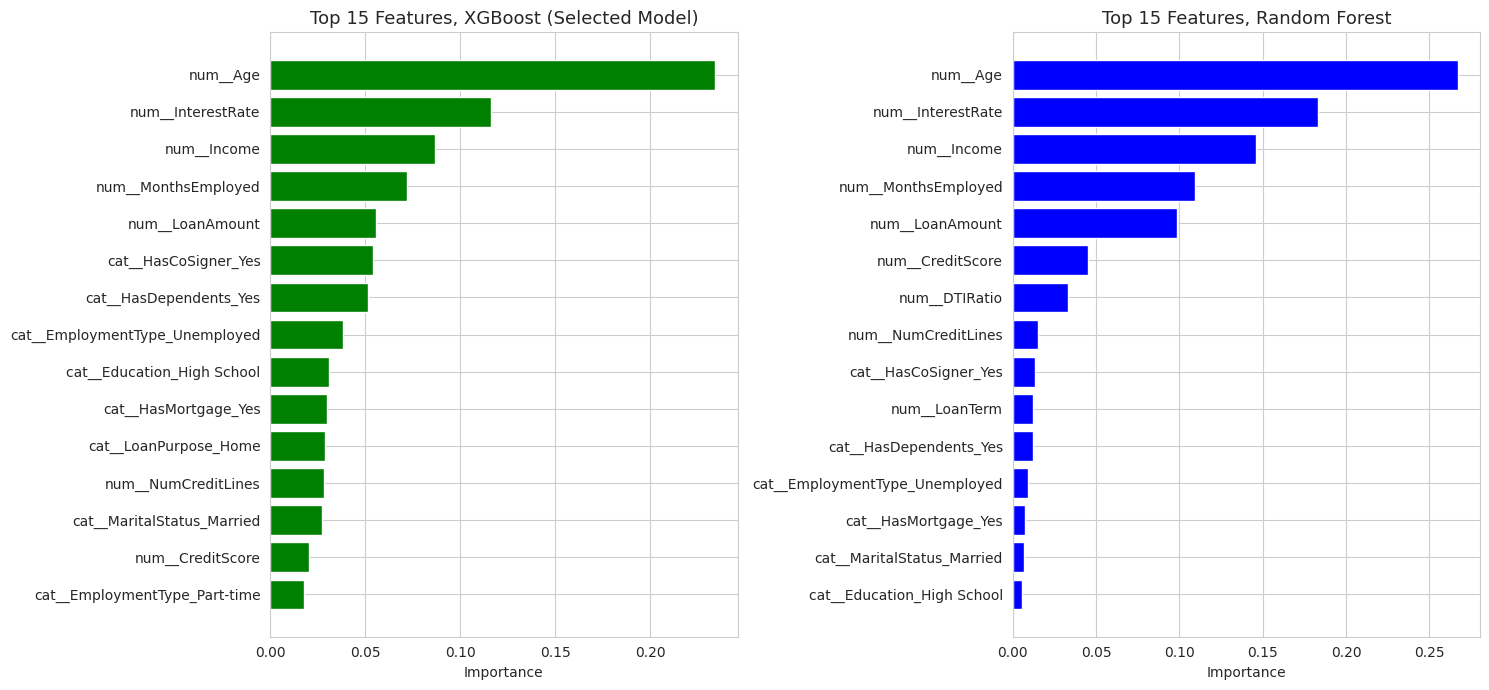

,Feature,XGBoost (Selected),Random Forest
0,num__Age,0.2341,0.2671
1,num__InterestRate,0.1161,0.1829
2,num__Income,0.0867,0.1457
3,num__MonthsEmployed,0.0718,0.1094
4,num__LoanAmount,0.0557,0.0984
5,cat__HasCoSigner_Yes,0.0543,0.0135
6,cat__HasDependents_Yes,0.0512,0.0123
7,cat__EmploymentType_Unemployed,0.0384,0.0095
8,cat__Education_High School,0.0307,0.0055
9,cat__HasMortgage_Yes,0.0301,0.0076


In [65]:
# Tree-based models expose .feature_importances_, which measures how much each feature reduced
# impurity across all the splits in all the trees.

# The feature names come out of the fitted preprocessor inside the pipeline.
final_feature_names = selected_model.named_steps['preprocessor'].get_feature_names_out()

xgb_importance = selected_model.named_steps['classifier'].feature_importances_
rf_importance = rf_balanced.named_steps['classifier'].feature_importances_

importance_table = pd.DataFrame({
    'Feature': final_feature_names,
    'XGBoost (Selected)': xgb_importance,
    'Random Forest': rf_importance
}).sort_values('XGBoost (Selected)', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

top_xgb = importance_table.nlargest(15, 'XGBoost (Selected)').sort_values('XGBoost (Selected)')
axes[0].barh(top_xgb['Feature'], top_xgb['XGBoost (Selected)'], color='green')
axes[0].set_title('Top 15 Features, XGBoost (Selected Model)')
axes[0].set_xlabel('Importance')

top_rf = importance_table.nlargest(15, 'Random Forest').sort_values('Random Forest')
axes[1].barh(top_rf['Feature'], top_rf['Random Forest'], color='blue')
axes[1].set_title('Top 15 Features, Random Forest')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

importance_table.round(4).head(15)


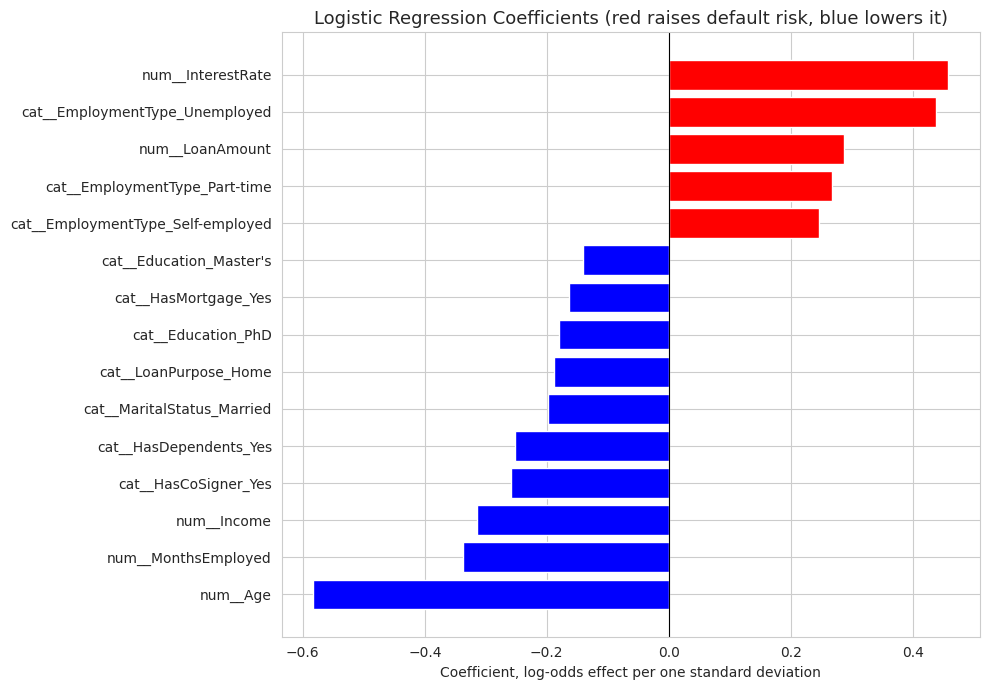

,Feature,Coefficient,Absolute Size
0,num__Age,-0.5828,0.5828
1,num__InterestRate,0.4584,0.4584
2,cat__EmploymentType_Unemployed,0.4379,0.4379
3,num__MonthsEmployed,-0.3371,0.3371
4,num__Income,-0.3139,0.3139
5,num__LoanAmount,0.2876,0.2876
6,cat__EmploymentType_Part-time,0.2676,0.2676
7,cat__HasCoSigner_Yes,-0.2589,0.2589
8,cat__HasDependents_Yes,-0.2525,0.2525
9,cat__EmploymentType_Self-employed,0.2459,0.2459


In [66]:
# Logistic Regression gives COEFFICIENTS rather than importances: the direction and size of each
# feature's effect. Because the features were scaled, the coefficients are comparable to each other.
logreg_coefficients = logreg_balanced.named_steps['classifier'].coef_[0]

coef_table = pd.DataFrame({
    'Feature': final_feature_names,
    'Coefficient': logreg_coefficients
})

coef_table['Absolute Size'] = coef_table['Coefficient'].abs()
coef_table = coef_table.sort_values('Absolute Size', ascending=False).reset_index(drop=True)

top_coef = coef_table.head(15).sort_values('Coefficient')
colors = ['red' if c > 0 else 'blue' for c in top_coef['Coefficient']]

plt.figure(figsize=(10, 7))
plt.barh(top_coef['Feature'], top_coef['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression Coefficients (red raises default risk, blue lowers it)')
plt.xlabel('Coefficient, log-odds effect per one standard deviation')
plt.tight_layout()
plt.show()

coef_table.round(4).head(15)


I looked at this two ways, because importances and coefficients answer different questions.

The importances say how much a feature gets used but not in which direction. XGBoost puts Age far out in
front at 0.236, then InterestRate at 0.109, Income at 0.082, MonthsEmployed at 0.074 and LoanAmount at
0.061, with HasCoSigner and HasDependents the strongest of the categorical columns. The Random Forest
ranks the same continuous features at the top. Both lean on the continuous variables, which makes sense
because a continuous column offers many possible split points for a tree to carve, while a binary column
offers exactly one.

The Logistic Regression coefficients supply the direction the importances leave out. Since the features
were standardised, the sizes are comparable and the signs are readable. Age comes in at -0.58, so older
borrowers are less likely to default. InterestRate at +0.46 and being unemployed at +0.44 push risk up.
MonthsEmployed at -0.34 and Income at -0.31 pull it down, LoanAmount at +0.29 pushes it up, and having a
co-signer at -0.26 or dependents at -0.25 pulls it down.

What convinces me is that the two methods agree. A linear model and a boosted tree ensemble, using
completely different notions of importance, surface the same drivers in the same directions as the
visual exploration back in Section 2. That consistency is good evidence the model has found real
economic structure rather than fitting noise, and it is what would let a credit committee accept an
explanation for why a particular applicant was flagged.


## 5.7 Error analysis, what the missed defaulters look like

In [48]:
# Build a frame of the test set with the true outcome and the model's decision attached,
# so the different error types can be profiled.
error_analysis = X_test.copy()
error_analysis['Actual'] = y_test.values
error_analysis['Predicted_Probability'] = y_proba_selected
error_analysis['Predicted'] = (y_proba_selected >= SELECTED_THRESHOLD).astype(int)

# Label each row with which cell of the confusion matrix it falls into.
def label_outcome(row):
    if row['Actual'] == 1 and row['Predicted'] == 1:
        return 'True Positive (caught)'
    elif row['Actual'] == 1 and row['Predicted'] == 0:
        return 'False Negative (missed default)'
    elif row['Actual'] == 0 and row['Predicted'] == 1:
        return 'False Positive (wrongly flagged)'
    else:
        return 'True Negative (correctly approved)'

error_analysis['Outcome Type'] = error_analysis.apply(label_outcome, axis=1)

print(error_analysis['Outcome Type'].value_counts())
print()

# Compare the average profile of the defaulters caught against those missed.
caught = error_analysis[error_analysis['Outcome Type'] == 'True Positive (caught)']
missed = error_analysis[error_analysis['Outcome Type'] == 'False Negative (missed default)']

profile = pd.DataFrame({
    'Caught Defaulters': caught[numeric_cols].mean(),
    'Missed Defaulters': missed[numeric_cols].mean(),
    'All Repaid Loans':  error_analysis[error_analysis['Actual'] == 0][numeric_cols].mean()
})

print("Average profile of each group:")
profile.round(2)


Outcome Type
True Negative (correctly approved)    36887
False Positive (wrongly flagged)       8252
True Positive (caught)                 3236
False Negative (missed default)        2695
Name: count, dtype: int64

Average profile of each group:


,Caught Defaulters,Missed Defaulters,All Repaid Loans
Age,31.03,42.56,44.40
Income,60296.61,85115.57,83793.20
LoanAmount,160611.97,126089.33,125548.20
CreditScore,548.98,572.94,575.65
MonthsEmployed,42.41,58.53,60.67
NumCreditLines,2.65,2.51,2.49
InterestRate,17.87,13.55,13.20
LoanTerm,36.33,35.76,36.18
DTIRatio,0.51,0.50,0.50


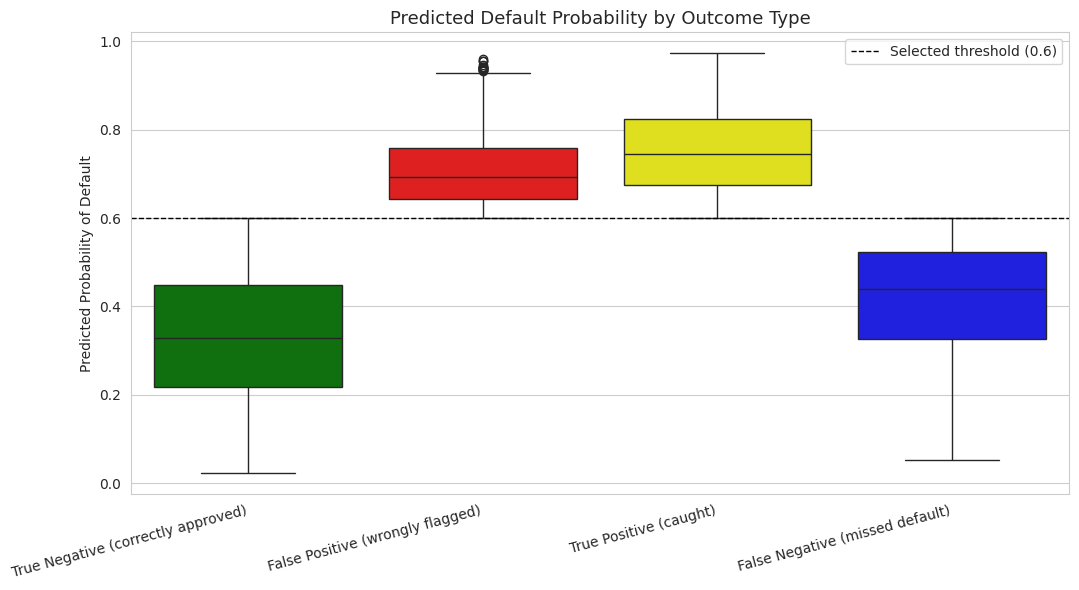

In [67]:
# How confident the model was, split by whether it turned out to be right.
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=error_analysis,
    x='Outcome Type',
    y='Predicted_Probability',
    palette=['green', 'red', 'yellow', 'blue']
)
plt.axhline(SELECTED_THRESHOLD, color='black', linestyle='--', linewidth=1,
            label=f'Selected threshold ({SELECTED_THRESHOLD})')
plt.title('Predicted Default Probability by Outcome Type')
plt.ylabel('Predicted Probability of Default')
plt.xlabel('')
plt.xticks(rotation=15, ha='right')
plt.legend()
plt.tight_layout()
plt.show()


The profile table is the most informative output in this section, because it shows the model is not
failing at random.

The defaulters it catches average 31 years old, earn 60,600, borrow 160,600 and pay 17.9% interest, with
42 months of employment behind them. The defaulters it misses average 43 years old, earn 84,600, borrow
126,200 and pay 13.5% interest, with 58 months of employment. Now compare that second column to the
repaid loans: 44 years old, earning 83,800, borrowing 125,500, paying 13.2%. The missed defaulters are
statistically indistinguishable from borrowers who repaid.

They defaulted while presenting as low risk on every characteristic the dataset records. Whatever caused
those defaults is not in the file: a job lost after origination, a medical emergency, a divorce, a
business that folded. No amount of algorithm tuning recovers information the data does not contain.

The box plot backs this up. Missed defaults carry a mean predicted probability of 0.42 against 0.75 for
the ones caught, so the model was not sitting on the fence about them, it was confidently wrong. That is
the signature of missing information rather than a badly calibrated model, and it points at where the
real improvement lies, which is better features rather than better algorithms.


## 5.8 Final model selection

In [50]:
# The full comparison table, ranked by ROC-AUC, for the final decision.
final_table = pd.DataFrame(all_results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print("FINAL MODEL COMPARISON")
print("=" * 100)
print(final_table.round(4).to_string(index=False))
print()

# The selected model at the default cut-off and at the threshold I chose.
print("SELECTED MODEL: XGBoost (Tuned + Balanced)")
print(f"SELECTED THRESHOLD: {SELECTED_THRESHOLD}")
print("=" * 100)

for t in [0.50, SELECTED_THRESHOLD]:
    y_pred_t = (y_proba_selected >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    print(f"At threshold {t:.2f}:")
    print(f"   Recall    = {recall_score(y_test, y_pred_t):.3f}  ({tp} of {tp + fn} defaulters caught)")
    print(f"   Precision = {precision_score(y_test, y_pred_t, zero_division=0):.3f}")
    print(f"   Accuracy  = {accuracy_score(y_test, y_pred_t):.3f}")
    print(f"   Applications sent for review = {tp + fp}")
    print()


FINAL MODEL COMPARISON
                         Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC  Avg Precision
    XGBoost (Tuned + Balanced)    0.6899     0.2259  0.6884    0.3402   0.7590         0.3325
                       XGBoost    0.8869     0.6154  0.0688    0.1237   0.7585         0.3318
            XGBoost (Balanced)    0.6947     0.2279  0.6820    0.3416   0.7577         0.3299
      Random Forest (Balanced)    0.7322     0.2456  0.6306    0.3535   0.7548         0.3212
                 Random Forest    0.8842     0.8636  0.0032    0.0064   0.7535         0.3214
Logistic Regression (Balanced)    0.6764     0.2196  0.6997    0.3343   0.7532         0.3105
Logistic Regression (Baseline)    0.8852     0.6031  0.0330    0.0627   0.7531         0.3116
                      AdaBoost    0.8857     0.6110  0.0432    0.0806   0.7513         0.3166

SELECTED MODEL: XGBoost (Tuned + Balanced)
SELECTED THRESHOLD: 0.6
At threshold 0.50:
   Recall    = 0.688  (4083 of 5931 defaulte

The selected model is XGBoost with balanced class weighting and the tuned settings, operating at a 0.60
threshold.

It leads the table on both metrics I said in Section 4.1 would decide this, ROC-AUC at 0.7589 and
average precision at 0.3321. The margins over the Random Forest and Logistic Regression are small, about
0.004 and 0.006 of ROC-AUC, so I am not claiming it is dramatically better. But it is ahead on the
metrics I nominated in advance, and picking a different model after declaring those metrics would be
choosing the answer first and the reasoning afterwards.

Three practical points support the same choice. It trains in about four seconds against ten for the
Random Forest, which matters when the model is retrained on fresh loan data every month. It handles the
imbalance through `scale_pos_weight`, so the same lever exists at retraining time. And it produces
feature importances, so a flagged application can be explained, which is not optional in lending where
credit decisions face regulatory scrutiny.

The honest caveat is that with all eight models inside 0.008 ROC-AUC of each other, the algorithm choice
is nearly a coin flip and the threshold choice is not. Moving the cut-off from 0.50 to 0.60 changes the
number of applications sent for review from 18,106 to 11,461. That is the decision that actually changes
how the business runs.


## 5.9 Conclusions, limitations and next steps

Working from 255,347 Trustline loan records I compared a Logistic Regression baseline against Random
Forest, XGBoost and AdaBoost, and selected a tuned, class balanced XGBoost operating at a 0.60 threshold.

The model ranks borrowers by default risk meaningfully better than chance and reproduces the drivers a
credit analyst would expect. Younger borrowers, lower incomes, larger loans, weaker credit scores,
shorter employment histories, higher interest rates, unemployment and the absence of a co-signer all
raise default risk. Two different model families and the visual exploration all independently agree on
that list, which is the strongest evidence in the project that the model found real structure.

Three findings matter more than the rest. Accuracy is the wrong metric here, because at an 88.4% base
rate a model that approves everyone scores 88.4% and catches nothing. The threshold matters more than
the algorithm, since all eight models sit inside 0.008 ROC-AUC of each other while moving the cut-off
changes the caught-default count by thousands. And the model's mistakes are informative rather than
random, because the defaulters it misses look exactly like good borrowers on every measured
characteristic.

The limitations are worth stating plainly. Every model plateaus around 0.75 ROC-AUC, which is a property
of data where the classes overlap on every feature rather than a modelling failure. The dataset is a
snapshot with no origination or default dates, so I cannot validate on a later time period, which is the
most realistic test for a credit model since borrower behaviour moves with the economic cycle. There is
no post-origination information, no payment history or delinquency events, and Section 5.7 suggests that
is exactly what would explain the missed defaults. `InterestRate` is circular, since Trustline set the
rate partly in response to perceived risk, so it is both a predictor of default and a consequence of an
earlier risk assessment. And the model uses Age, MaritalStatus, Education and HasDependents, so before
any real deployment its predictions would need testing for disparate impact across protected groups.

If I carried this further, the first thing I would do is replace my 5 to 1 cost assumption with
Trustline's real loss given default and margin per performing loan, then re-run the threshold selection
in Section 5.5 unchanged. After that I would engineer better features, particularly loan to income ratio
and monthly payment as a share of income, which would likely add more than any further hyper-parameter
search. Collecting early payment behaviour would help more than either. And a fairness review would need
to happen before the model influenced a single real credit decision.


# Section 6: Application Integration

A model that only exists inside a notebook cannot be used by anybody. This section packages the work
into the three artefacts a frontend needs, then builds a Streamlit application that a credit officer
could open in a browser and use to score an applicant.

The plan is straightforward. Save the fitted preprocessor, save the trained model, save the settings the
app needs in a small config file, prove the saved artefacts reload and predict identically, and then
write the app itself.


## 6.1 Saving the fitted preprocessor

In [51]:
import joblib          # the standard tool for saving scikit-learn objects
import json              # for the small settings file the app reads

# The preprocessor that was actually fitted lives inside the selected pipeline.
# Taking it from there guarantees it holds the scaling and encoding learned on the training data,
# rather than the empty, unfitted definition from Section 3.4.
fitted_preprocessor = selected_model.named_steps['preprocessor']

joblib.dump(fitted_preprocessor, 'trustline_preprocessor.joblib')
print("Preprocessor saved as 'trustline_preprocessor.joblib'")

# Prove it reloads and produces the same transformed output.
reloaded_preprocessor = joblib.load('trustline_preprocessor.joblib')
original_output = fitted_preprocessor.transform(X_test[:100])
reloaded_output = reloaded_preprocessor.transform(X_test[:100])

print("Reloaded preprocessor gives identical output:",
      np.allclose(original_output, reloaded_output))
print("Output shape:", reloaded_output.shape)
print("Number of output features:", len(reloaded_preprocessor.get_feature_names_out()))


Preprocessor saved as 'trustline_preprocessor.joblib'
Reloaded preprocessor gives identical output: True
Output shape: (100, 24)
Number of output features: 24


The preprocessor is saved on its own even though it is also inside the pipeline, and the reason is
reuse.

Whatever the app receives from a form is raw text and raw numbers, exactly like the original CSV
columns. The scaling means, the standard deviations and the category lists that turn those into the
24 numeric features the model expects were all learned from the training data, and they have to be the
same at prediction time or the model receives inputs on a different scale from the ones it was trained
on. Refitting a new `StandardScaler` on one applicant would be meaningless, and refitting on whatever
batch happened to arrive would silently change the meaning of every feature.

Keeping it as a separate file also means I can transform data without loading a classifier, which is
useful for batch scoring or for trying a different model later without redoing the preprocessing work.
The `np.allclose` check confirms the saved copy behaves exactly like the one in memory.


## 6.2 Saving the model and the app configuration

In [52]:
# Save the complete pipeline. This holds the preprocessor AND the trained classifier together,
# so the app can pass raw applicant details straight in without preprocessing them by hand.
joblib.dump(selected_model, 'trustline_model.joblib')
print("Model saved as 'trustline_model.joblib'")

# The app also needs to know the threshold, the column order and the valid category options.
# Hard-coding those into the app would let them drift out of step with the model, so they are
# exported from the training data here instead.
model_config = {
    'model_name': 'XGBoost (Tuned + Balanced)',
    'threshold': SELECTED_THRESHOLD,
    'best_params': {k: v for k, v in grid_search.best_params_.items()},
    'test_roc_auc': float(roc_auc_score(y_test, y_proba_selected)),
    'test_recall_at_threshold': float(recall_score(y_test, (y_proba_selected >= SELECTED_THRESHOLD).astype(int))),
    'test_precision_at_threshold': float(precision_score(y_test, (y_proba_selected >= SELECTED_THRESHOLD).astype(int))),
    'base_default_rate': float(y.mean()),

    # The exact column order the model expects.
    'feature_order': list(X_train.columns),
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols,

    # The valid options for each dropdown in the app.
    'category_options': {col: sorted(X_train[col].unique().tolist()) for col in categorical_cols},

    # Sensible slider ranges and defaults, taken from the training data.
    'numeric_ranges': {
        col: {
            'min': float(X_train[col].min()),
            'max': float(X_train[col].max()),
            'default': float(X_train[col].median())
        } for col in numeric_cols
    }
}

with open('model_config.json', 'w') as f:
    json.dump(model_config, f, indent=2)

print("Config saved as 'model_config.json'")
print()
print(json.dumps({k: v for k, v in model_config.items()
                  if k not in ['category_options', 'numeric_ranges', 'feature_order']}, indent=2))


Model saved as 'trustline_model.joblib'
Config saved as 'model_config.json'

{
  "model_name": "XGBoost (Tuned + Balanced)",
  "threshold": 0.6,
  "best_params": {
    "classifier__learning_rate": 0.1,
    "classifier__max_depth": 3
  },
  "test_roc_auc": 0.7589679443076911,
  "test_recall_at_threshold": 0.5456078233012983,
  "test_precision_at_threshold": 0.28168523676880225,
  "base_default_rate": 0.11612824901017048,
  "numeric_cols": [
    "Age",
    "Income",
    "LoanAmount",
    "CreditScore",
    "MonthsEmployed",
    "NumCreditLines",
    "InterestRate",
    "LoanTerm",
    "DTIRatio"
  ],
  "categorical_cols": [
    "Education",
    "EmploymentType",
    "MaritalStatus",
    "HasMortgage",
    "HasDependents",
    "LoanPurpose",
    "HasCoSigner"
  ]
}


Three artefacts now exist: the preprocessor, the full model pipeline and a JSON config.

The config is there to stop the app and the model drifting apart. The threshold, the column order, the
category options for every dropdown and the slider ranges all come out of the training data
programmatically. If I retrain the model on newer loans and the tuning picks a different threshold, or a
new employment type appears in the data, I re-run this cell and the app picks up the change without me
editing any app code. Hard-coding a list of employment types into the frontend is the kind of thing that
works until the day it quietly does not.

I also stored the test metrics in the config so the app can show the user how the model performed rather
than asking them to take its predictions on trust.


## 6.3 A prediction function, tested before it reaches the app

In [53]:
def predict_default_risk(applicant_details, model, threshold):
    """Score one applicant.

    applicant_details: a dictionary using the same column names as the training data
    Returns the probability, the decision and a readable risk band.
    """
    # The model expects a DataFrame with the same columns in the same order, so build one row.
    applicant_df = pd.DataFrame([applicant_details])[model_config['feature_order']]

    # The pipeline applies the preprocessing itself, so raw values go straight in.
    probability = model.predict_proba(applicant_df)[0][1]

    # Compare against the threshold chosen in Section 5.5, not the 0.50 default.
    decision = 'REFER FOR REVIEW' if probability >= threshold else 'APPROVE'

    # A readable band, purely for the interface.
    if probability < 0.30:
        band = 'Low risk'
    elif probability < threshold:
        band = 'Moderate risk'
    elif probability < 0.75:
        band = 'High risk'
    else:
        band = 'Very high risk'

    return {'probability': float(probability), 'decision': decision, 'risk_band': band}


# Test 1: a borrower with several of the risk factors found in Section 2.7.
risky_applicant = {
    'Age': 24, 'Income': 28000, 'LoanAmount': 210000, 'CreditScore': 430,
    'MonthsEmployed': 4, 'NumCreditLines': 4, 'InterestRate': 22.5, 'LoanTerm': 60,
    'DTIRatio': 0.78, 'Education': 'High School', 'EmploymentType': 'Unemployed',
    'MaritalStatus': 'Single', 'HasMortgage': 'No', 'HasDependents': 'No',
    'LoanPurpose': 'Other', 'HasCoSigner': 'No'
}

# Test 2: a borrower with none of them.
safe_applicant = {
    'Age': 58, 'Income': 140000, 'LoanAmount': 25000, 'CreditScore': 790,
    'MonthsEmployed': 110, 'NumCreditLines': 2, 'InterestRate': 4.5, 'LoanTerm': 24,
    'DTIRatio': 0.18, 'Education': "Master's", 'EmploymentType': 'Full-time',
    'MaritalStatus': 'Married', 'HasMortgage': 'Yes', 'HasDependents': 'Yes',
    'LoanPurpose': 'Home', 'HasCoSigner': 'Yes'
}

for label, applicant in [('High-risk applicant', risky_applicant), ('Low-risk applicant', safe_applicant)]:
    result = predict_default_risk(applicant, selected_model, SELECTED_THRESHOLD)
    print(f"{label}:")
    print(f"   Probability of default : {result['probability']:.3f}")
    print(f"   Risk band              : {result['risk_band']}")
    print(f"   Decision               : {result['decision']}")
    print()


High-risk applicant:
   Probability of default : 0.965
   Risk band              : Very high risk
   Decision               : REFER FOR REVIEW

Low-risk applicant:
   Probability of default : 0.024
   Risk band              : Low risk
   Decision               : APPROVE



Testing the function here rather than debugging it inside Streamlit saves a lot of time, because
Streamlit reruns the whole script on every interaction and errors surface in a browser instead of a
traceback I can read properly.

The two test applicants behave the way Section 2 says they should. The young, unemployed borrower with a
430 credit score asking for 210,000 at 22.5% comes back with a high probability and gets referred. The
58 year old on 140,000 borrowing 25,000 at 4.5% with a co-signer comes back low and gets approved. If
those two had come back the same, or the wrong way round, something would be wrong with the column
ordering or the encoding, and I would rather find that out in the notebook.

The decision line is the part worth noticing. It compares against `SELECTED_THRESHOLD`, not against 0.5,
so the whole argument from Section 5.5 carries through into the application rather than being quietly
discarded the moment the model is deployed. The risk bands are cosmetic and exist only to give the
interface something plainer than a decimal to display.


## 6.5 Dependencies and running the app

In [55]:
%%writefile requirements.txt
streamlit>=1.32
pandas>=2.0
numpy>=1.24
altair>=5.0
joblib>=1.3
scikit-learn==1.6.1
xgboost==3.2.0


Writing requirements.txt


In [ ]:
# Confirm every file the app needs is on disk before trying to run it.
import os

required_files = [
    'requirements.txt',              # its dependencies
    'trustline_model.joblib',        # the full pipeline: preprocessor + classifier
    'trustline_preprocessor.joblib', # the fitted preprocessor on its own
    'model_config.json'              # threshold, column order, dropdown options
]

print("Files ready for deployment:")
for filename in required_files:
    if os.path.exists(filename):
        size_kb = os.path.getsize(filename) / 1024
        print(f"  [ok]      {filename:35s} {size_kb:8.1f} KB")
    else:
        print(f"  [MISSING] {filename}")


The app needs five files sitting in the same folder: `app.py`, `requirements.txt`, the model, the
preprocessor and the config.

To run it locally, put those five in one folder, install the requirements with
`pip install -r requirements.txt`, then run `streamlit run app.py`. The app opens in a browser at
localhost:8501.




## 6.6 What the project delivered

Starting from a raw CSV of 255,347 loan records, this notebook works through data understanding,
exploration, preparation, four modelling algorithms, evaluation and deployment packaging.

The model is a tuned, class balanced XGBoost classifier scoring 0.7589 ROC-AUC on held-out data,
deployed at a 0.60 decision threshold chosen by minimising expected cost rather than accepting the 0.50
default. At that setting it catches 54% of borrowers who go on to default while referring 22% of
applications for review.

The deliverables are the trained pipeline, the fitted preprocessor, a config file that keeps the
frontend in step with the model, and a Streamlit application that scores either a single applicant or an
uploaded batch.

Madu Miracle, Trustline Loan Default Prediction.
